**Capitulo 2 - HANS**

In [2]:
print("Welcome to Machine Learning!")

Welcome to Machine Learning!


This project requires Python 3.7 or above:

In [4]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [6]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

# Get the Data

*Welcome to Machine Learning Housing Corp.! Your task is to predict median house values in Californian districts, given a number of features from these districts.*

## Download the Data

In [10]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

C:\Users\rsantos\AppData\Local\Temp\ipykernel_31784\2839428726.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


## Take a Quick Look at the Data Structure

In [12]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [14]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [15]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


The following cell is not shown either in the book. It creates the `images/end_to_end_project` folder (if it doesn't already exist), and it defines the `save_fig()` function which is used through this notebook to save the figures in high-res for the book.

In [17]:
# extra code – code to save the figures as high-res PNGs for the book

IMAGES_PATH = Path() / "images" / "end_to_end_project"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [18]:
import os

# Carpeta desde donde se abrió el notebook
ruta_carpeta = os.getcwd()
print(ruta_carpeta)


C:\Users\rsantos\Downloads\HANS


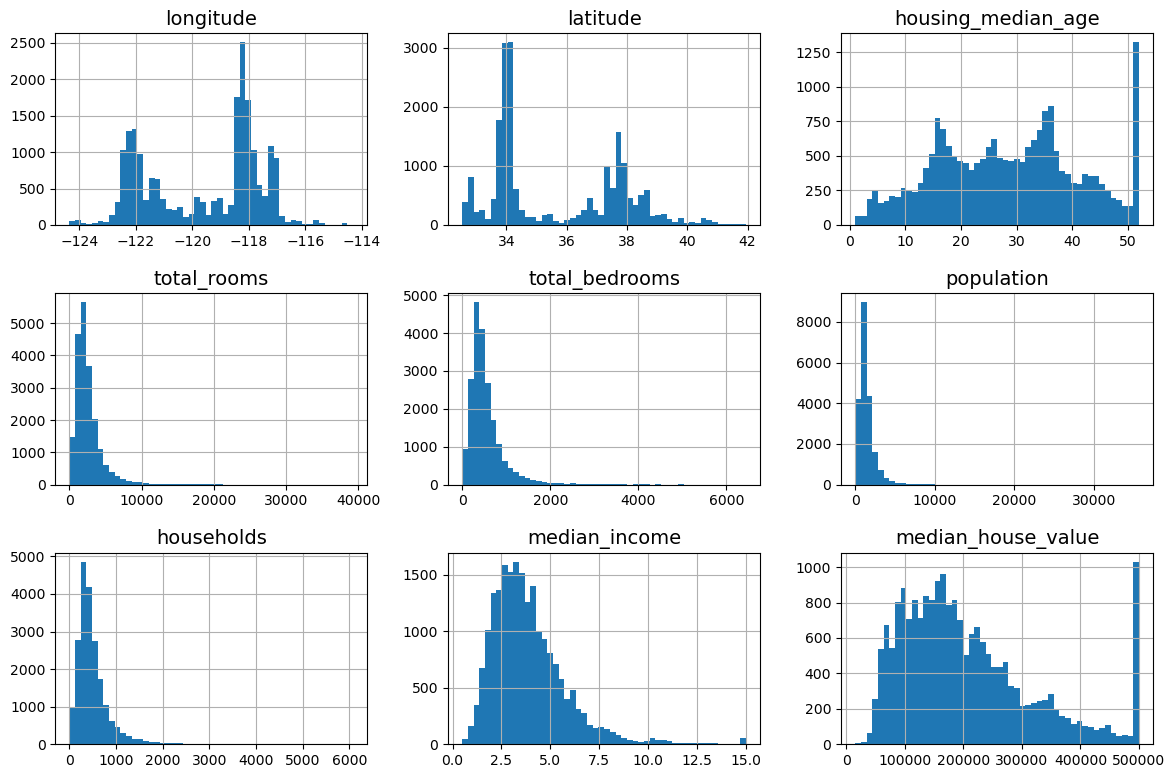

In [19]:
import matplotlib.pyplot as plt

# extra code – the next 5 lines define the default font sizes
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(12, 8))
save_fig("attribute_histogram_plots")  # extra code
plt.show()

## Create a Test Set

In [21]:
import numpy as np

def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [22]:
train_set, test_set = shuffle_and_split_data(housing, 0.2)
len(train_set)

16512

In [23]:
len(test_set)

4128

To ensure that this notebook's outputs remain the same every time we run it, we need to set the random seed:

In [25]:
np.random.seed(42)

Sadly, this won't guarantee that this notebook will output exactly the same results as in the book, since there are other possible sources of variation. The most important is the fact that algorithms get tweaked over time when libraries evolve. So please tolerate some minor differences: hopefully, most of the outputs should be the same, or at least in the right ballpark.

Note: another source of randomness is the order of Python sets: it is based on Python's `hash()` function, which is randomly "salted" when Python starts up (this started in Python 3.3, to prevent some denial-of-service attacks). To remove this randomness, the solution is to set the `PYTHONHASHSEED` environment variable to `"0"` _before_ Python even starts up. Nothing will happen if you do it after that. Luckily, if you're running this notebook on Colab, the variable is already set for you.

In [28]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [29]:
housing_with_id = housing.reset_index()  # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [30]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [31]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

El **muestreo aleatorio** es generalmente adecuado si el conjunto de datos es lo suficientemente grande, pero si no lo es, corre el riesgo de introducir un **sesgo de muestreo significativo**.

## Diferencia entre `train_test_split y ShuffleSplit`

### 1. `train_test_split`

`train_test_split` realiza **una sola división** del dataset en entrenamiento y prueba.  
Es sencillo, directo y muy usado cuando solo se necesita una partición.

**Características:**
- Solo una división.
- Aleatoriza los datos por defecto.
- Permite definir `test_size` y `train_size`.



### 2. `ShuffleSplit`

`ShuffleSplit` genera **múltiples divisiones aleatorias** independientes.  
Es útil cuando quieres evaluar tu modelo varias veces con distintas combinaciones de train/test.

**Características:**
- Permite crear varias divisiones (`n_splits`).
- Cada división baraja los datos.
- Similar a usar `train_test_split` repetidamente.



##  Resumen rápido

| Método              | Nº Divisiones | Aleatorización | Uso Principal |
|--------------------|--------------|----------------|---------------|
| `train_test_split` | 1            | Sí             | División simple. |
| `ShuffleSplit`     | Varias       | Sí             | Evaluación repetida y robusta. |


ShuffleSplit no garantiza que no haya sesgo.
Ayuda a reducir algunos tipos de sesgo, pero no elimina todos. 

In [34]:
test_set["total_bedrooms"].isnull().sum()

44

Cuando los empleados de una empresa de encuestas deciden llamar a $1,000$ personas para hacerles algunas preguntas, no eligen a $1,000$ persona al azar en una guía telefónica. Intentan asegurarse de que estas $1,000$ personas sean representativas de toda la población, con respecto a las preguntas que quieren hacer.  Por ejemplo, la población estadounidense es de $51.1\%$ mujeres y $48.9\%$ hombres, por lo que una encuesta bien realizada en EE.UU intentaría mantener está proporción en la muestra

Para calcular la probabilidad de que una muestra aleatoria de 1000 personas contenga menos del 48,5 % de mujeres o más del 53,5 % de mujeres cuando la proporción de mujeres en la población es del 51,1 %, utilizamos la [binomial distribution](https://en.wikipedia.org/wiki/Binomial_distribution) . El método `cdf()` de la distribución binomial nos da la probabilidad de que el número de mujeres sea igual o menor que el valor dado.

In [36]:
# extra code – shows how to compute the 10.7% proba of getting a bad sample

from scipy.stats import binom

sample_size = 1000
ratio_female = 0.511
proba_too_small = binom(sample_size, ratio_female).cdf(485 - 1)
proba_too_large = 1 - binom(sample_size, ratio_female).cdf(535)
print(proba_too_small + proba_too_large)

0.10736798530929942


If you prefer simulations over maths, here's how you could get roughly the same result:

In [38]:
import numpy as np
np.random.seed(42)  
# Fijamos la semilla para que los resultados sean reproducibles

# Generamos 100,000 simulaciones, cada una con "sample_size" individuos
# Cada número aleatorio está entre 0 y 1
# Luego comparamos cada número con ratio_female:
#   - True  -> mujer
#   - False -> hombre
samples = (np.random.rand(100_000, sample_size) < ratio_female).sum(axis=1)
# Con .sum(axis=1) contamos cuántas mujeres hay en cada simulación
# Calculamos la proporción de simulaciones donde el número de mujeres
# es menor de 485 o mayor de 535
# Esto mide qué tan probable es que el resultado se salga de ese rango
probabilidad = ((samples < 485) | (samples > 535)).mean()
probabilidad

0.1071

In [39]:
import sys
# Agregar la ruta donde se encuentra tu archivo .py
sys.path.append(Path.cwd())

# Ahora puedes importar tu módulo
import Funciones_ML as ML

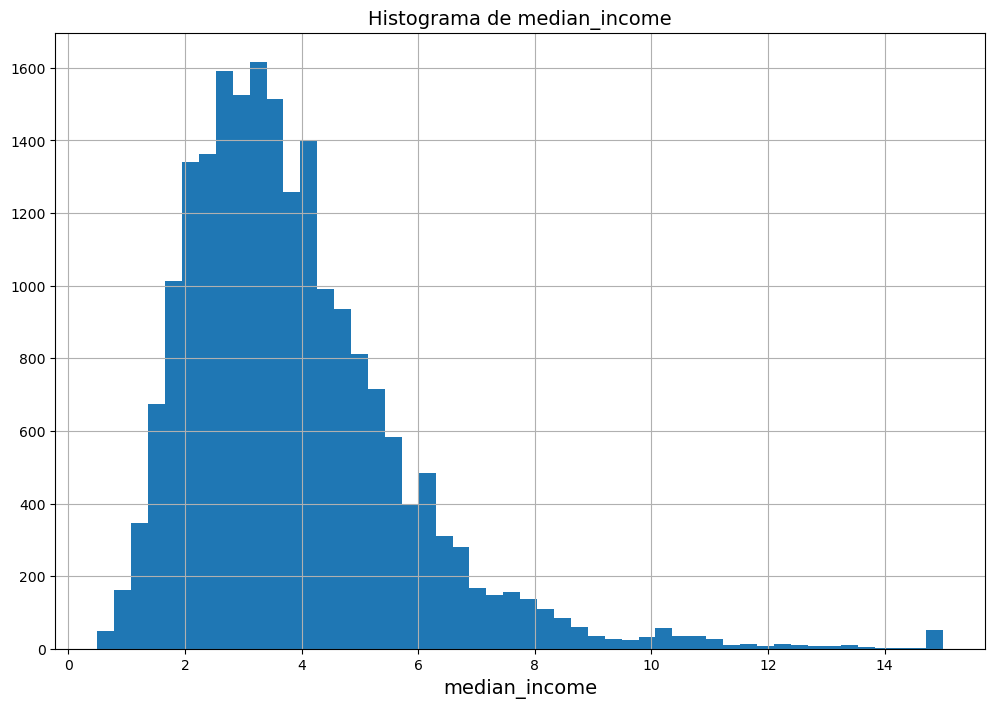

In [40]:
ML.plot_hist(housing, 'median_income')

C:\Users\rsantos\Downloads\HANS\imagenes\Visualizacion\Histograma_housing_all.png


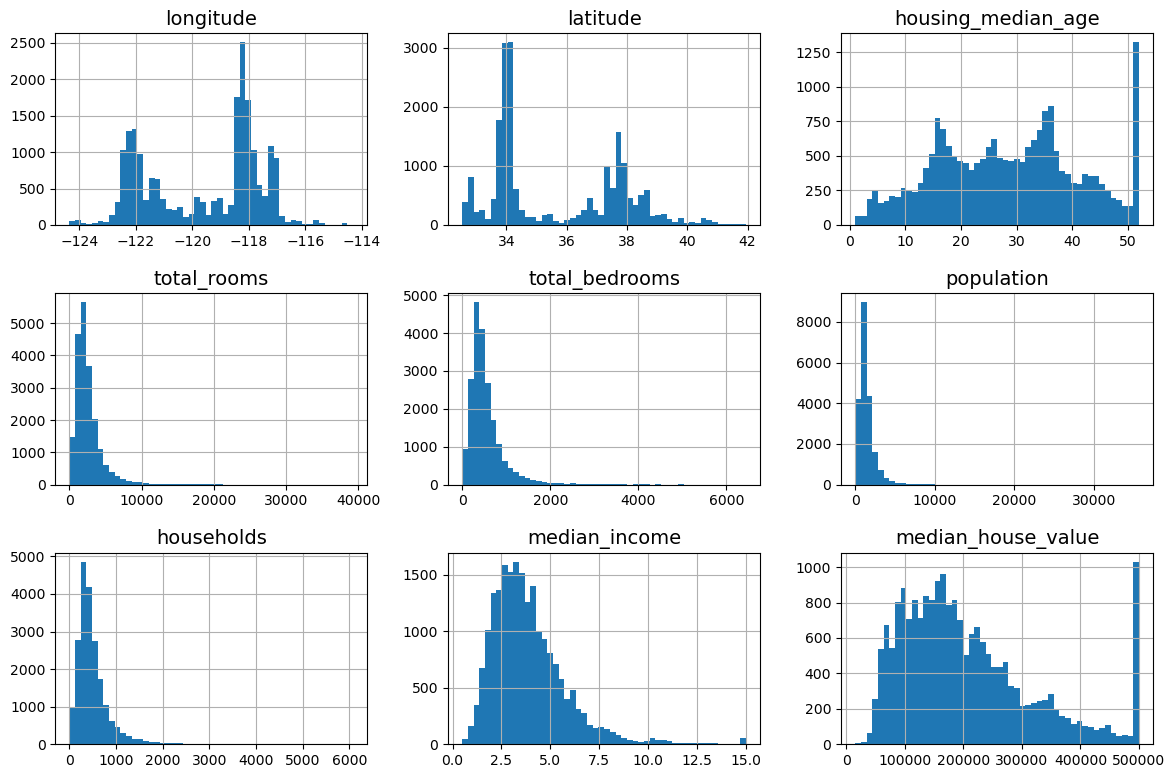

In [41]:
ML.plot_histograms(housing, save_carpeta = 'Visualizacion', save_name="Histograma_housing_all")

In [42]:
import Funciones_ML as ML
import importlib
importlib.reload(ML)


<module 'Funciones_ML' from 'C:\\Users\\rsantos\\Downloads\\HANS\\Funciones_ML.py'>

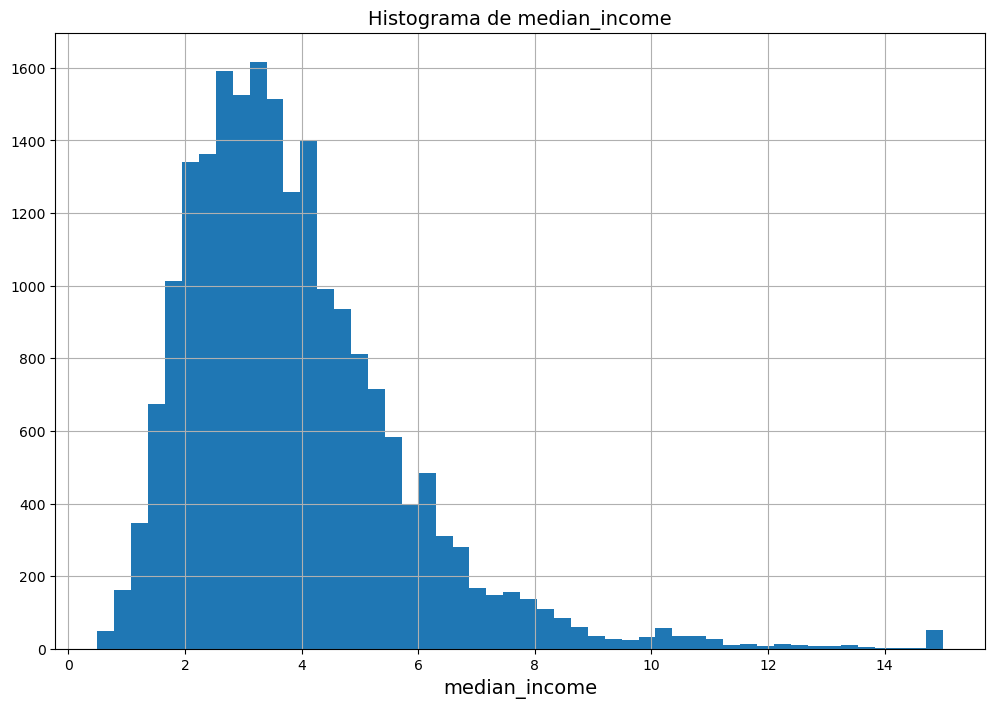

In [43]:
ML.plot_hist(housing, "median_income" )

In [44]:
housing.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [45]:
# Crear una nueva columna llamada "income_cat" basada en los valores de "median_income"
housing["income_cat"] = pd.cut(
    
    # Columna que queremos dividir en intervalos
    housing["median_income"],
    
    # Definimos los límites de los intervalos (bins)
    # Por defecto, los intervalos son: abiertos por la izquierda y cerrados por la derecha (a, b]
    # Intervalos resultantes:
    # (0.0, 1.5]  -> categoría 1
    # (1.5, 3.0]  -> categoría 2
    # (3.0, 4.5]  -> categoría 3
    # (4.5, 6.0]  -> categoría 4
    # (6.0, ∞]    -> categoría 5
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    
    # Etiquetas asignadas a cada intervalo
    labels=[1, 2, 3, 4, 5],
    
    # include_lowest=True asegura que el valor mínimo de la columna (ej: 0.0) entre en el primer intervalo
    include_lowest=True
)


In [46]:
housing.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


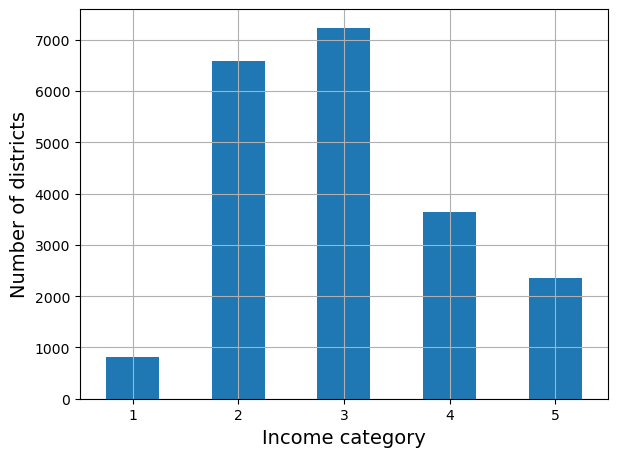

In [47]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
save_fig("housing_income_cat_bar_plot")  # extra code
plt.show()

Tener múltiples divisiones puede ser útil si desea estimar mejor el rendimiento de su modelo, como verá al abordar la **Validación cruzada**

In [49]:
# Importa StratifiedShuffleSplit desde scikit-learn, que permite hacer divisiones de datos
# manteniendo la proporción de clases en la variable objetivo o categórica.
from sklearn.model_selection import StratifiedShuffleSplit

# Crea un objeto StratifiedShuffleSplit con los siguientes parámetros:
# n_splits=10 -> realizará 10 divisiones diferentes de los datos
# test_size=0.2 -> el 20% de los datos se usarán como conjunto de prueba
# random_state=42 -> asegura reproducibilidad en la división de datos
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# Lista vacía donde se guardarán las divisiones de entrenamiento y prueba
strat_splits = []

# Itera sobre los índices generados por splitter.split()
# "housing" es tu DataFrame completo
# "housing['income_cat']" es la variable categórica usada para estratificar
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    
    # Crea el conjunto de entrenamiento usando los índices de entrenamiento
    strat_train_set_n = housing.iloc[train_index]
    
    # Crea el conjunto de prueba usando los índices de prueba
    strat_test_set_n = housing.iloc[test_index]
    
    # Agrega esta división (entrenamiento y prueba) a la lista de splits
    strat_splits.append([strat_train_set_n, strat_test_set_n])


In [50]:
strat_train_set, strat_test_set = strat_splits[0]

In [51]:
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY,2
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN,5
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND,2
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND,2
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,500001.0,<1H OCEAN,4
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,88800.0,INLAND,2
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,148800.0,NEAR OCEAN,3
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,500001.0,<1H OCEAN,3


In [52]:
housing.shape

(20640, 11)

In [53]:
strat_train_set.shape

(16512, 11)

In [54]:
strat_test_set.shape

(4128, 11)

Es mucho más corto obtener una única división estratificada, con el **stratify** de argumento.

In [56]:
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [57]:
housing["income_cat"].value_counts() / len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [58]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

Como se puede observar, el conjunto de prueba generado mediante **muestreo estratificado** tiene proporciones de categorías de ingresos casi idénticas a las del conjunto de datos completo

In [60]:
# extra code – computes the data for Figure 2–10

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(housing),
    "Stratified %": income_cat_proportions(strat_test_set),
    "Random %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error %"] = (compare_props["Stratified %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error %"] = (compare_props["Random %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

,Overall %,Stratified %,Random %,Strat. Error %,Rand. Error %
Income Category,,,,,
1,3.98,4.00,4.24,0.36,6.45
2,31.88,31.88,30.74,-0.02,-3.59
3,35.06,35.05,34.52,-0.01,-1.53
4,17.63,17.64,18.41,0.03,4.42
5,11.44,11.43,12.09,-0.08,5.63


El conjunto de prueba generado mediante **muestreo aleatorio** está sesgado.

In [62]:
# Itera sobre los conjuntos de entrenamiento y prueba que ya fueron estratificados
for set_ in (strat_train_set, strat_test_set):
    print(set_)
    # Elimina la columna "income_cat" del DataFrame
    # axis=1 indica que se está eliminando una columna (no una fila)
    # inplace=True modifica directamente el DataFrame original sin crear una copia
    
    #set_.drop("income_cat", axis=1, inplace=True)


       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
13096    -122.42     37.80                52.0       3321.0          1115.0   
14973    -118.38     34.14                40.0       1965.0           354.0   
3785     -121.98     38.36                33.0       1083.0           217.0   
14689    -117.11     33.75                17.0       4174.0           851.0   
20507    -118.15     33.77                36.0       4366.0          1211.0   
...          ...       ...                 ...          ...             ...   
14207    -118.40     33.86                41.0       2237.0           597.0   
13105    -119.31     36.32                23.0       2945.0           592.0   
19301    -117.06     32.59                13.0       3920.0           775.0   
19121    -118.40     34.06                37.0       3781.0           873.0   
19888    -122.41     37.66                44.0        431.0           195.0   

       population  households  median_income  media

# Discover and Visualize the Data to Gain Insights



# Explorar y visualizar los datos para obtener información.


Asegúrese de haber reservado el conjunto de prueba y de que solo esté explorando el conjunto de entrenamiento.

In [65]:
housing = strat_train_set.copy()

## Visualizing Geographical Data

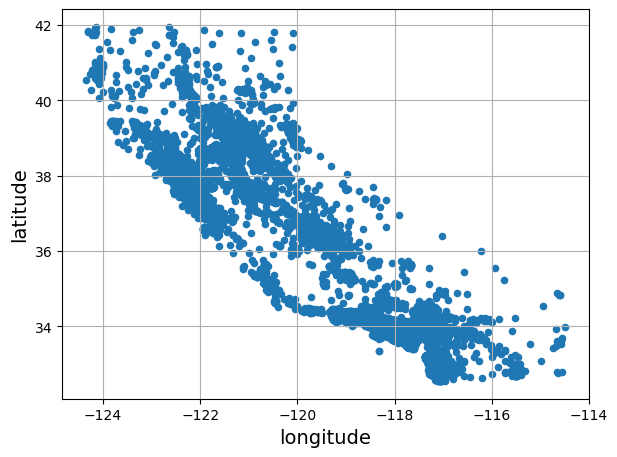

In [67]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)
save_fig("bad_visualization_plot")  # extra code
plt.show()

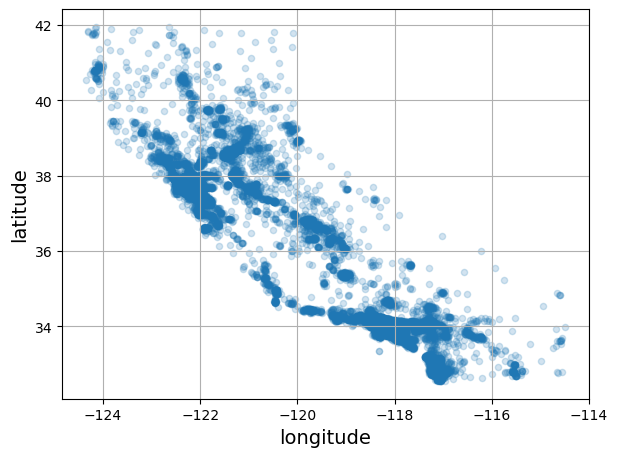

In [68]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
save_fig("better_visualization_plot")  # extra code
plt.show()

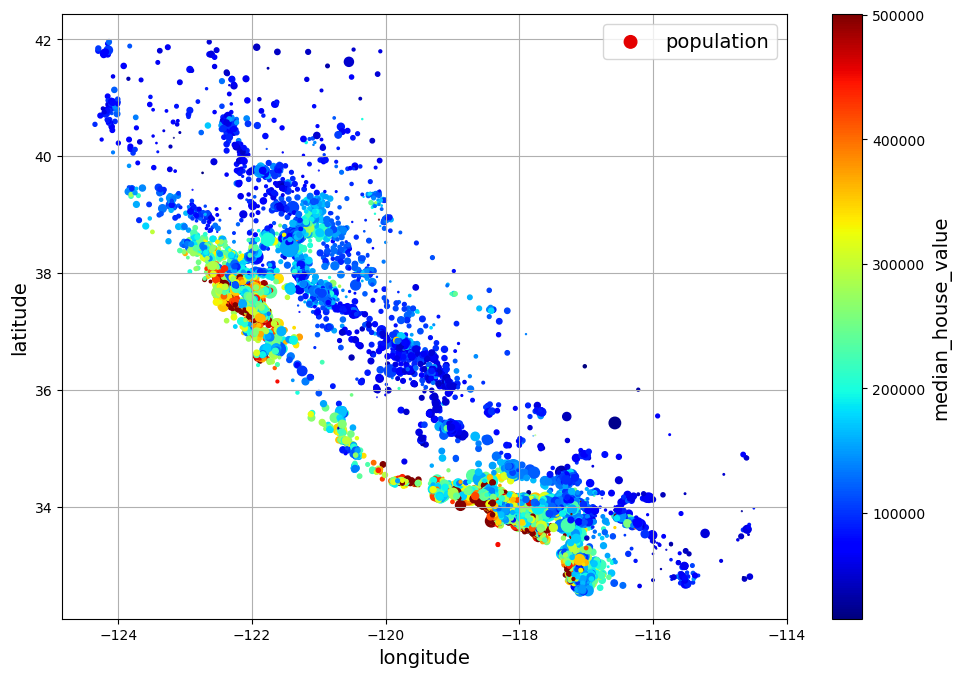

In [69]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=housing["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
save_fig("housing_prices_scatterplot")  # extra code
plt.show()

The argument `sharex=False` fixes a display bug: without it, the x-axis values and label are not displayed (see: https://github.com/pandas-dev/pandas/issues/10611).

The next cell generates the first figure in the chapter (this code is not in the book). It's just a beautified version of the previous figure, with an image of California added in the background, nicer label names and no grid.

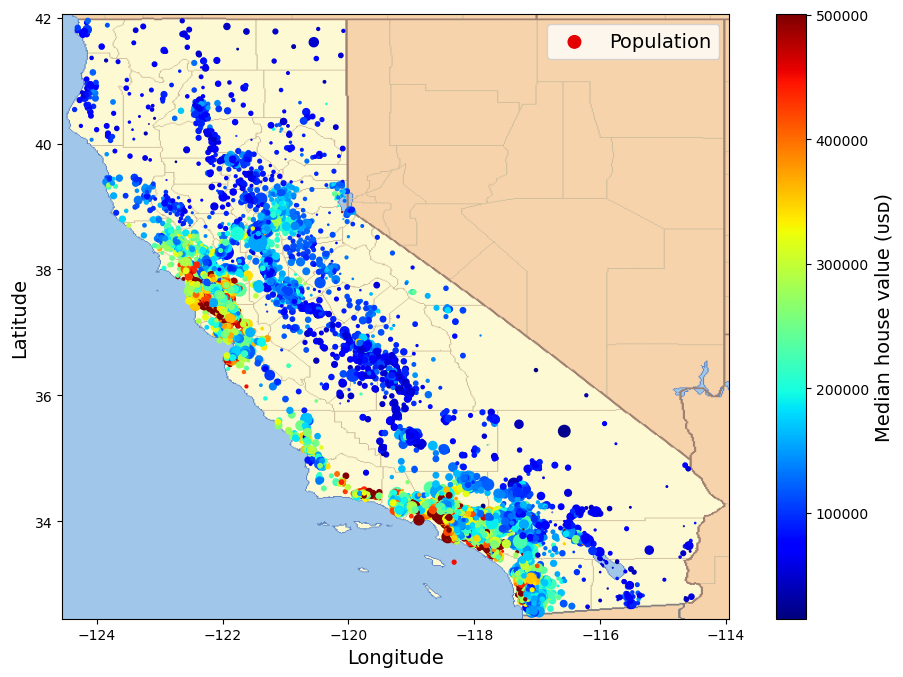

In [72]:
# extra code – this cell generates the first figure in the chapter

# Download the California image
filename = "california.png"
if not (IMAGES_PATH / filename).is_file():
    homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
    url = homl3_root + "images/end_to_end_project/" + filename
    print("Downloading", filename)
    urllib.request.urlretrieve(url, IMAGES_PATH / filename)

housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.plot(
             kind="scatter", x="Longitude", y="Latitude",
             s=housing_renamed["Population"] / 100, label="Population",
             c="Median house value (ᴜsᴅ)", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))

california_img = plt.imread(IMAGES_PATH / filename)
axis = -124.55, -113.95, 32.45, 42.05
plt.axis(axis)
plt.imshow(california_img, extent=axis)

save_fig("california_housing_prices_plot")
plt.show()

## Buscando correlaciones ¶
Nota: desde Pandas 2.0.0, el argumento  `numeric_only` predeterminado es `False` , por lo que debemos establecerlo explícitamente en `True` para evitar un error.



 **Fórmula del coeficiente de correlación de Pearson**

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2}
\sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$

donde:

- $x_i, y_i$ son los valores de cada variable,
- $\bar{x}$, $\bar{y}$ son sus medias,
- $n$ es el número de observaciones.

In [74]:
corr_matrix = housing.corr(numeric_only=True)

In [75]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

In [76]:
ML.correlacion_con_objetivo(housing, "median_house_value") #Otra forma de obtener la información

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

El coeficiente de correlación oscila entre $-1$ y $1$.
* Cuando se acerca a $1$, significa que existe una fuerte correlación positiva.
* Cuando el coeficiente se acerca a $-1$, significa que existe una fuerte correlación negativa.
* Cuando los coeficientes cercanos a $0$ indican que no existe correlación lineal.

Variables con correlación ≥ 0.5 con 'median_house_value':
        Variable  Correlación
0  median_income      0.68838


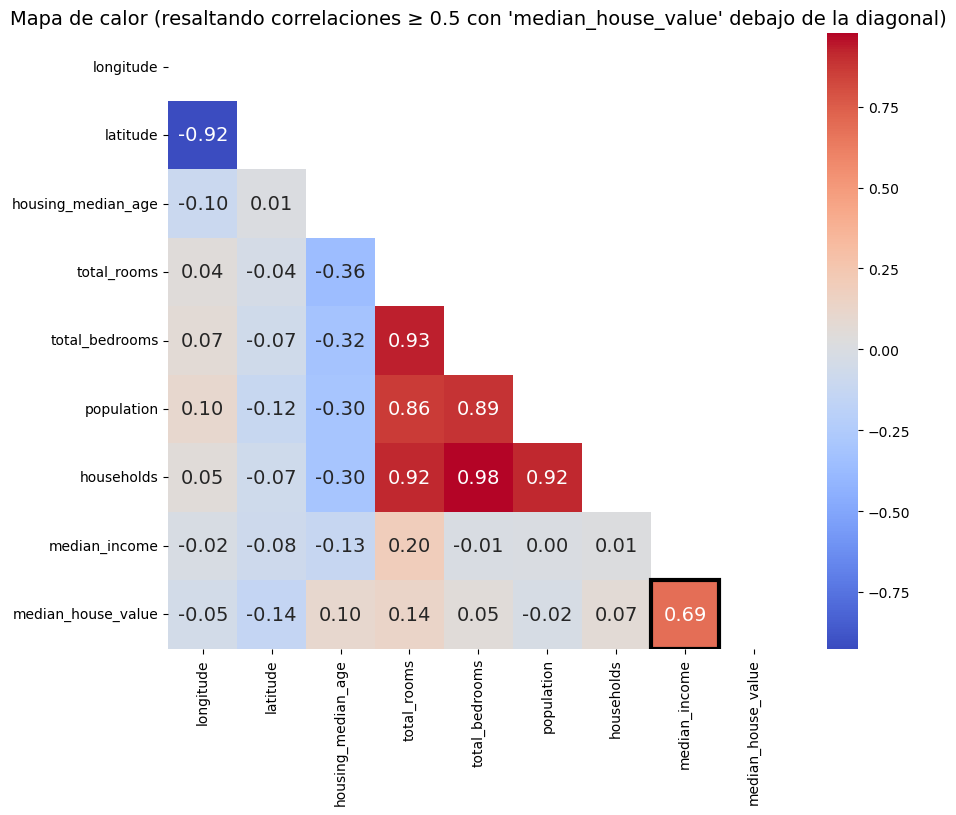

,Variable,Correlación
0,median_income,0.68838


In [78]:
ML.variables_mas_correlacionadas_grafico(housing,  "median_house_value")

In [79]:
# Obtener la correlación con 'median_house_value', ordenada de mayor a menor
correlaciones = corr_matrix["median_house_value"].sort_values(ascending=False)
print(f"correlaciones: \n \n{correlaciones}")


# Guardar los nombres de las 4 variables más correlacionadas, excluyendo 'median_house_value'
attributes = correlaciones.index.drop("median_house_value")[:4].tolist()
print(f"\n \nattributes: {attributes}")

correlaciones: 
 
median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

 
attributes: ['median_income', 'total_rooms', 'housing_median_age', 'households']


Se decide centrarse en algunos atributos (4) prometedores que parecen estar más correlacionados con el "median_house_value" (valor medio de la vivienda).

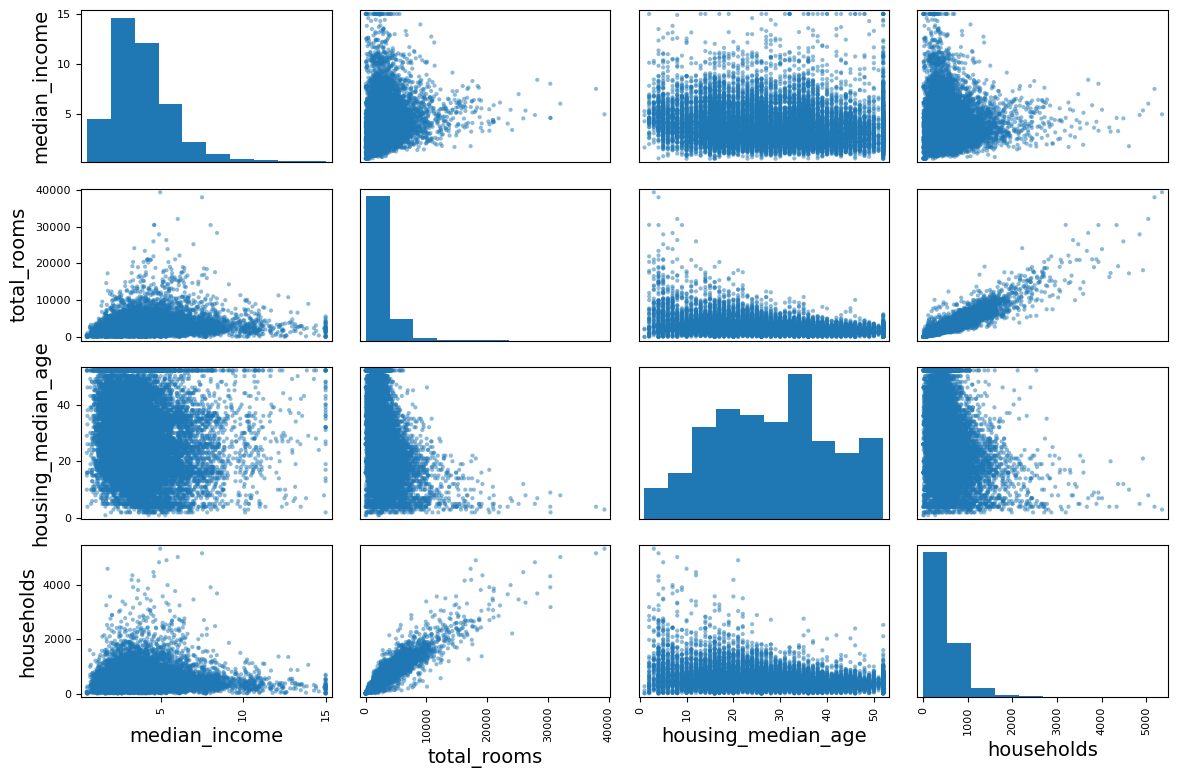

In [81]:
from pandas.plotting import scatter_matrix

scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")  # extra code
plt.show()

Nos quedamos con el atributo más prometedor (correlacionado) para predecir el valor medio de la vivienda es el "median_income" (ingreso medio)

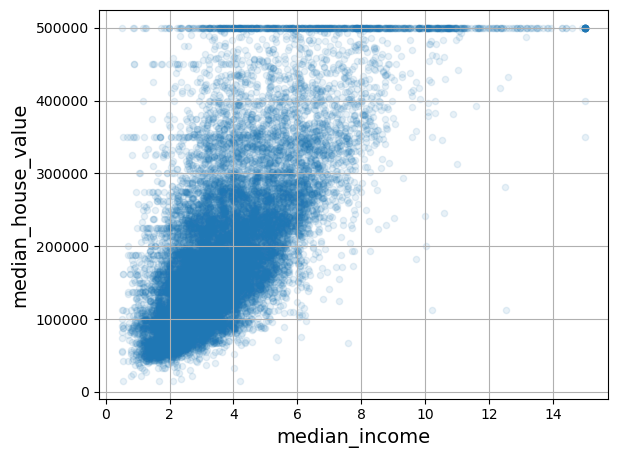

In [83]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
save_fig("income_vs_house_value_scatterplot")  # extra code
plt.show()

## Experimentando con combinaciones de atributos

In [85]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"] #Numero de habitaciones por hogar
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"] #Número de dormitorios por habitaciones
housing["people_per_house"] = housing["population"] / housing["households"]  #Población por hogar

In [86]:
housing.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat,rooms_per_house,bedrooms_ratio,people_per_house
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY,2,3.211799,0.335742,1.524178
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN,5,5.504202,0.180153,1.865546
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND,2,5.334975,0.200369,2.768473
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND,2,5.351282,0.203881,2.365385
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN,3,3.725256,0.277371,1.631399


In [87]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

`bedrooms_ratio`  esta mucho más correlacionado con el valor medio de la vivienda que el número total de habitaciones o dormitorios.

# Preparar los datos para los algoritmos de aprendizaje automático ¶
Volvamos al conjunto de entrenamiento original y separemos el objetivo (tenga en cuenta qu `strat_train_set.drop()` )crea una copia`strat_train_set`  la columna, en realidad no se modificaa`strat_train_set` a sí mismo, a menos que pase`inplace=True`e):

In [89]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [90]:
housing.shape

(16512, 10)

In [91]:
housing_labels.shape

(16512,)

## Data Cleaning

In [93]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   ocean_proximity     16512 non-null  object  
 9   income_cat          16512 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.3+ MB


In [94]:
housing["total_bedrooms"].isnull().sum() #Cuenta las filas en total_bedroms en donde hay nulos

168

In the book 3 options are listed to handle the NaN values:

```python
housing.dropna(subset=["total_bedrooms"], inplace=True)    # option 1 
 #Elimina todas las filas donde total_bedrooms tenga valores nulos (NaN).
#Consecuencias:
#Se pierden datos (filas completas).
#Útil si hay pocos valores faltantes.

housing.drop("total_bedrooms", axis=1)       # option 2 Elimina la columna completa total_bedrooms.

median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True) #Calcula la mediana de la columna total_bedrooms. Rellena los valores faltantes (NaN) con esa mediana.
```

For each option, we'll create a copy of `housing` and work on that copy to avoid breaking `housing`. We'll also show the output of each option, but filtering on the rows that originally contained a NaN value.

In [96]:
null_rows_idx = housing.isnull().any(axis=1) #Nos quedamos con el índice en donde tenemos los valores nulos
housing.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND,3
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN,3
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN,3
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN,4
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN,5


### **Opción 1**
Elimina todas las filas donde "total_bedrooms" tenga valores nulos (NaN).

Consecuencias:
* Se pierden datos (filas completas).
* Útil si hay pocos valores faltantes.

In [98]:
housing_option1 = housing.copy()

housing_option1.dropna(subset=["total_bedrooms"], inplace=True)  # option 1

housing_option1.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat


In [99]:
housing_option1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16344 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16344 non-null  float64 
 1   latitude            16344 non-null  float64 
 2   housing_median_age  16344 non-null  float64 
 3   total_rooms         16344 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16344 non-null  float64 
 6   households          16344 non-null  float64 
 7   median_income       16344 non-null  float64 
 8   ocean_proximity     16344 non-null  object  
 9   income_cat          16344 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.3+ MB


#### **Opción 2**

Elimina toda la columna

In [101]:
housing_option2 = housing.copy()

housing_option2.drop("total_bedrooms", axis=1, inplace=True)  # option 2

housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity,income_cat
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND,3
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN,3
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN,3
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN,4
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN,5


In [102]:
housing_option2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   population          16512 non-null  float64 
 5   households          16512 non-null  float64 
 6   median_income       16512 non-null  float64 
 7   ocean_proximity     16512 non-null  object  
 8   income_cat          16512 non-null  category
dtypes: category(1), float64(7), object(1)
memory usage: 1.7+ MB


### **Opción 3**
Imputa los nulos con valores estadísticos (media, moda, mediana, constante)

In [104]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

housing_option3 = housing.copy()

median = housing["total_bedrooms"].median()
housing_option3["total_bedrooms"].fillna(median, inplace=True)  # option 3

housing_option3.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962,INLAND,3
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115,<1H OCEAN,3
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917,<1H OCEAN,3
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033,<1H OCEAN,4
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020,<1H OCEAN,5


**SimpleImputer** : La ventaja es que almacenará el valor de la mediana de cada característica, lo que permitirá imputar valores faltantes no solo en el conjunto de entrenamiento, sino también en el conjunto de validación, el conjunto de prueba y cualquier dato nuevo que se introduzca en el modelo.


### Estimadores

Cualquier objeto que pueda estimar parámetros a partir de un conjunto de datos se denomina **estimador** (Ejemplo: *SimpleImputer* es un estimador). El método realiza la estimación *fit()* y toma un conjutno de datos como parámetro, o dos para algoritmos de aprendizaje supervisado.


### Transformadores

Algunos estimados (como a *SimpleImputer*) también pueden transformar un conjunto de datos; estos se denominan *transformadores*. La transformación la realiza el método *transform()* con el conjunto de datos a transformar como parámetro. Devuele el conjunto de datos transformados. Esta transformación generalmente se basa en los parámetros aprendidos, como en el caso de *SimpleImputer*

In [106]:
# Importa la clase SimpleImputer de scikit-learn, usada para rellenar valores faltantes (NaN)
from sklearn.impute import SimpleImputer

# Crea una instancia del imputador configurada para reemplazar valores faltantes
# con la mediana de cada columna
imputer = SimpleImputer(strategy="median") #

Separar los atributos numéricos para utilizar la `"median"` estrategia (ya que no se puede calcular sobre atributos de texto como `ocean_proximity`):
])


In [108]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16344 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   ocean_proximity     16512 non-null  object  
 9   income_cat          16512 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.8+ MB


In [109]:
housing_num = housing.select_dtypes(include=[np.number]) #Solo las variables númericas
housing_num.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')

In [110]:
imputer.fit(housing_num) #Imputer caclula la mediana de cada atributo y almacena los resultados en su stattistics_

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [111]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [112]:
# Redondear los valores a enteros
valores_redondeados =np.round(imputer.statistics_, 3)
# Para mostrar los valores con 2 decimales sin notación científica
np.set_printoptions(suppress=True, precision=2)

print(valores_redondeados)


[-118.51   34.26   29.   2125.    434.   1167.    408.      3.54]


Check that this is the same as manually computing the median of each attribute:

In [114]:
housing_num.median().values

array([-118.51,   34.26,   29.  , 2125.  ,  434.  , 1167.  ,  408.  ,
          3.54])

Transform the training set:

In [116]:
X = imputer.transform(housing_num) #Reemplazar los valores faltantes con las medianas

In [117]:
print(type(X)) #Para saber el tipo de X

<class 'numpy.ndarray'>


In [118]:
X

array([[-122.42,   37.8 ,   52.  , ..., 1576.  , 1034.  ,    2.1 ],
       [-118.38,   34.14,   40.  , ...,  666.  ,  357.  ,    6.09],
       [-121.98,   38.36,   33.  , ...,  562.  ,  203.  ,    2.43],
       ...,
       [-117.06,   32.59,   13.  , ..., 2814.  ,  760.  ,    4.06],
       [-118.4 ,   34.06,   37.  , ..., 1725.  ,  838.  ,    4.15],
       [-122.41,   37.66,   44.  , ...,  682.  ,  212.  ,    3.28]])

In [119]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

Encapsulamos *X* en un DataFrame y recupera los nombres de columna y el índice de *housing_num*

In [121]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [122]:
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292
...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455


Observamos como quedan las filas que anteriormente tenían nulos, como quedan después de imputar los valores de la mediana en la columna **total_bedrooms**

In [124]:
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
14452,-120.67,40.50,15.0,5343.0,434.0,2503.0,902.0,3.5962
18217,-117.96,34.03,35.0,2093.0,434.0,1755.0,403.0,3.4115
11889,-118.05,34.04,33.0,1348.0,434.0,1098.0,257.0,4.2917
20325,-118.88,34.17,15.0,4260.0,434.0,1701.0,669.0,5.1033
14360,-117.87,33.62,8.0,1266.0,434.0,375.0,183.0,9.8020


In [125]:
imputer.strategy #Con esto, podemos saber el método que se utilizo en el transformador.

'median'

In [126]:
#from sklearn import set_config
#
# set_config(transform_output="pandas")  # scikit-learn >= 1.2

### ATÍPICOS

Ahora dejemos de lado algunos casos atípicos:

In [128]:
import pandas as pd

# DataFrame pequeño
df = pd.DataFrame({
    "x": [10, 12, 11, 13, 12, 200],   # 200 es un outlier
    "y": [5, 7, 6, 5, 6, -100]        # -100 es un outlier
})

df

,x,y
0,10,5
1,12,7
2,11,6
3,13,5
4,12,6
5,200,-100


In [129]:

import pandas as pd
from sklearn.ensemble import IsolationForest

# DataFrame pequeño
df = pd.DataFrame({
    "x": [10, 12, 11, 13, 12, 200],   # 200 es un outlier
    "y": [5, 7, 6, 5, 6, -100]        # -100 es un outlier
})

# Creamos el modelo
isf = IsolationForest(random_state=42, contamination=0.15) 
# contamination=0.15 -> asumimos que 15% de puntos son outliers (1 de 6)


# Entrenamos y predecimos
df["outlier"] = isf.fit_predict(df)

print(df)

     x    y  outlier
0   10    5        1
1   12    7        1
2   11    6        1
3   13    5        1
4   12    6        1
5  200 -100       -1


If you wanted to drop outliers, you would run the following code:

In [131]:
#housing = housing.iloc[outlier_pred == 1]
#housing_labels = housing_labels.iloc[outlier_pred == 1]

## Manejo de Texto y Atributos Categóricos

Ahora vamos a preprocesar la función de entrada categórica, `ocean_proximity`:

In [133]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


### OrdinalEncoder

In [135]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [136]:
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

Puede obtener la lista de categorías mediante la variable `categories_` de instancia.

Es una lista que contiene un arrray unidimensional de categorias para cada atributo categórico (en este caso, una lista que contiene un solo array, ya que solo hay un atributo categórico).

In [138]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

Un porblema con esta representación es que los algoritmos de aprendizaje automático asumirán que dos valores cercanos son más similares que dos valores distantes. Esto puede ser adecuado en algunos casos (p. eje, para categorías ordenadas como "malo", "regular", "bueno", y "excelente") pero obviamente este no es el caso.


### OneHotEncoder

In [140]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

In [141]:
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

In [142]:
print(type(housing_cat_1hot))

<class 'scipy.sparse._csr.csr_matrix'>


`housing_cat_1hot` es una **matriz dispersa de Scipy**. Una matriz dispersa es una representación muy eficiente para matrices que contienen principalmente ceros. De hecho, internamente solo almacena los valores distintos de cero y sus posiciones. Esta matriz ahorra mucha memoría y acelerá los cálculos. 

Puede usar una matriz dispersa principlamente coomo un array 2D normal, pero si desea convertirla en un array Numpy (denso), simplemmente ocupe el método `toarray()`

In [144]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

Alternativa, puede configurarlo `sparse_output=False`

al crear  *OneHotEncoder*, 
en cuyo caso el método *transform* devolverá directamente una matriz numpy regular (densa)

In [146]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

se puede obtener la lista de categorías, de la siguiente manera:

In [148]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [149]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [150]:
cat_encoder.transform(df_test)

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [151]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
pd.get_dummies(df_test_unknown)

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True




 **¿Qué es `handle_unknown`?**

- Es un parámetro de los codificadores categóricos de scikit-learn, como:
  - `OneHotEncoder`
  - `OrdinalEncoder`
- Define **qué hacer cuando aparece una categoría nueva que no estaba presente en el entrenamiento**.


`cat_encoder.handle_unknown = "ignore"`

* Ignora la categoría desconocida.

* Genera un vector de ceros para esa columna codificada.

* Evita que el pipeline falle durante transform().




In [153]:
cat_encoder.handle_unknown = "ignore" #Indica como manejar categorías que no se han visto 
cat_encoder.transform(df_test_unknown)

array([[0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

]Al ajustar cualquier estimador de Scikit-Lear mediante un Dataframe, este almacena los nombres de las columnas en el atributo  `feature_names_in_`

In [155]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

Los transformadores también ofrecen un método  `get_feature_names_out()` 

para construir un DataFrame en torno a la salida del transformador.

In [157]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [158]:
# Transformamos las columnas categóricas del DataFrame 'df_test_unknown' 
# usando el codificador 'cat_encoder' (OneHotEncoder)
# Esto convierte las variables categóricas en variables numéricas binarias.
df_output = pd.DataFrame(
    cat_encoder.transform(df_test_unknown),  # Aplica la transformación a los datos desconocidos
    columns=cat_encoder.get_feature_names_out(),  # Asigna nombres a las columnas según el codificador
    index=df_test_unknown.index  # Mantiene el mismo índice que el DataFrame original
)


In [159]:
df_output

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0


In [160]:
df_test_unknown.head(2)

,ocean_proximity
0,<2H OCEAN
1,ISLAND


## Escalado de características

En la mayoría de los algoritmos de aprendizaje automático, los atributos numéricos de entrada deben estar en escalas similares para que el modelo funcione correctamente. Si los valores de los distintos atributos varían mucho en magnitud, los algoritmos pueden dar más importancia a las variables con números más grandes y casi ignorar las que tienen valores más pequeños, aunque sean igualmente relevantes. Esto ocurre porque muchos modelos, como la regresión lineal, las redes neuronales o los métodos basados en distancia, calculan métricas que dependen directamente de la magnitud de los números. Escalar las variables —por ejemplo, normalizándolas o estandarizándolas— asegura que todas contribuyan de manera equilibrada, mejorando la eficiencia y la precisión del modelo.

**Al igual que con todos los estimadores, es importante ajustar los escaladores únicamente a los datos de entrenamiento**

Si bien los valores del conjunto de entrenamiento siempre se escalarán al rango específicado, si los nuevos datos contienen valores atípicos, estos podrían escalarse fuera del rango. Para evitar esto, simplemente configure el hiperparámetro `clip=True` .

Esto es útil si tus datos tienen valores atípicos, porque sin clip=True, un outlier podría generar valores fuera del rango definido.

In [162]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

In [163]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

A diferencia de **MinMaxScaler**, el **StandardScaler** no restringe los valores a un rango específico. Sin embargo, la *StandardScaler* se ve mucho menos afectada por los valores atípicos.

Cuando la distribución de una característica presenta una *cola pesada* (es decir, cuando los valores alejados de la media no son exponencialmente raros), tanto el escalado  **MinMaxScaler** como el  **StandardScaler** reducirán la mayoría de los valores a un rango pequeño. Los modelos de Machine Learning generalmente no toleran esto. Por lo tanto, **antes de escalar la característica, primero debe transformarla para reducir la cola pesasa y, si es posible, hacer que la distribucción sea aproximadamente simétrica**

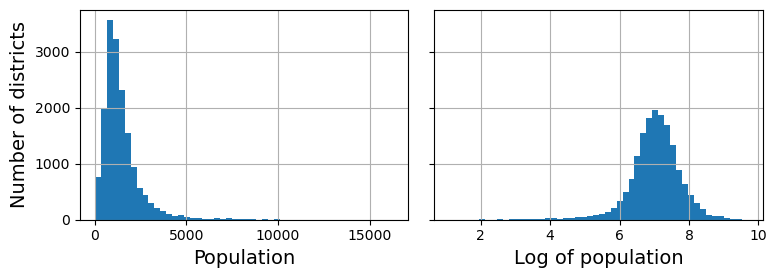

In [166]:
# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

¿Y si reemplazamos cada valor por su percentil?

### Segmentar la característica.

Otro enfoque para gestionar características de cola pesada consiste en *segmentar la característica*. Esto siginifica dividir su distribución en segmentos de tamaño aproximadamente igual y reemplazar cada valor de característica con el índice del segmento al que pertenece. Por ejemplo, se podría reemplazar cada valor con su percentil. Segmentar con segmentos de tamaño igual da como resultado una característica con una **distribución casi uniforme**, por lo que no es necesario escalar más.

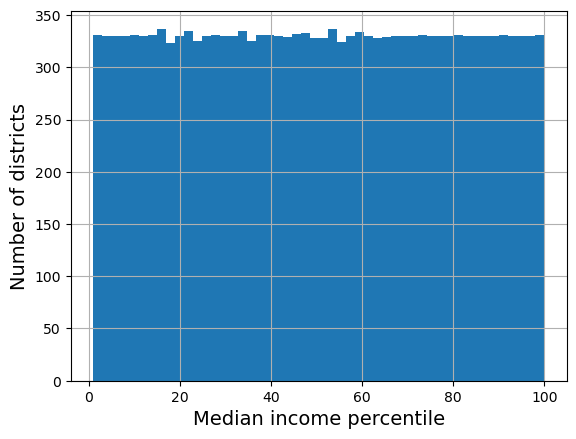

In [169]:
# extra code – just shows that we get a uniform distribution
percentiles = [np.percentile(housing["median_income"], p)
               for p in range(1, 100)]
flattened_median_income = pd.cut(housing["median_income"],
                                 bins=[-np.inf] + percentiles + [np.inf],
                                 labels=range(1, 100 + 1))
flattened_median_income.hist(bins=50)
plt.xlabel("Median income percentile")
plt.ylabel("Number of districts")
plt.show()
# Note: incomes below the 1st percentile are labeled 1, and incomes above the
# 99th percentile are labeled 100. This is why the distribution below ranges
# from 1 to 100 (not 0 to 100).

# RBF (Radial Basis Function)

In [171]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

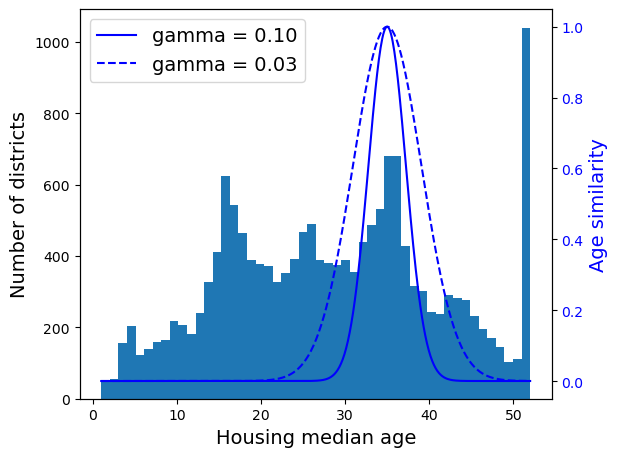

In [172]:
# extra code – this cell generates Figure 2–18

ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
save_fig("age_similarity_plot")
plt.show()

También puede ser necesario transformar los **valores objetivo**. Por ejemplo, si la distribución del objetivo tiene una cola pesada, se puede optar por aplicar el logaritmo al objetivo. Sin embargo, al hacerlo, el modelo de regresión predirá el logaritmo de la variable objetivo, no su valor directo. Por lo tanto, será necesario aplicar la función inversa posteriormente para obtener los valores originales. 

El método ``` inverse_transform()```    

facilita el cálculo de la inversa de sus transformaciones.

In [174]:
housing_labels.shape

(16512,)

In [175]:
housing.shape

(16512, 10)

In [176]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame()) #Estandar Escaler 

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]  # pretend this is new data

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

In [177]:
predictions

array([[131997.15],
       [299359.36],
       [146023.37],
       [138840.34],
       [192016.62]])

### TransformerTargetRegressor

**¿Qué es `TransformedTargetRegressor`?**

`TransformedTargetRegressor` es un modelo en la librería `scikit-learn` que combina un **transformador** y un **regresor**. Su función principal es aplicar una transformación a la variable objetivo (la que intentamos predecir) antes de ajustarla a un modelo de regresión. Esto es útil cuando la variable objetivo tiene una distribución que no es adecuada para el modelo o cuando los valores están en una escala que dificulta el aprendizaje.

**Componentes de `TransformedTargetRegressor`:**

1. **Transformador**: Este componente transforma la variable objetivo (`y`). Por ejemplo, puede usar transformaciones como escalado, normalización o logaritmos. Esto puede mejorar el rendimiento del modelo de regresión, especialmente si la variable objetivo tiene una distribución sesgada.
   
2. **Regresor**: Después de que la variable objetivo haya sido transformada, el modelo de regresión (como un `RandomForestRegressor` o `LinearRegression`) es entrenado utilizando los datos transformados.

El objetivo es transformar la variable objetivo de forma que el modelo pueda aprender de manera más efectiva, y luego aplicar la transformación inversa a las predicciones para obtener los resultados en la escala original.

**¿Cómo funciona `TransformedTargetRegressor`?**

El flujo de trabajo de este modelo es el siguiente:

1. **Preprocesamiento de la variable objetivo**: Se aplica una transformación a la variable `y` antes de entrenar el modelo de regresión. Esto puede ser, por ejemplo, escalado o normalización.
   
2. **Entrenamiento del modelo**: El modelo de regresión se ajusta a los datos transformados. Es decir, el modelo aprende a predecir los valores de `y` transformados.

3. **Predicción**: Cuando el modelo realiza una predicción, los resultados se devuelven en la escala transformada. Luego, se aplica la transformación inversa a las predicciones para que estén en la escala original de la variable objetivo.

Esto es útil cuando la variable objetivo tiene propiedades no ideales, como una distribución sesgada o valores extremos.

**Casos de uso comunes**

1. **Distribuciones sesgadas**: Si la variable objetivo sigue una distribución sesgada, la transformación puede ayudar a estabilizar la varianza y hacer que el modelo sea más efectivo.
   
2. **Escalado**: Si la variable objetivo tiene una escala diferente a la de las características de entrada (por ejemplo, muy grande o muy pequeña), un transformador puede ponerla en una escala más adecuada para el modelo de regresión.


**¿Puede utilizarse para clasificación?**

No, el `TransformedTargetRegressor` no está diseñado para tareas de clasificación, ya que su objetivo es predecir una variable continua (de tipo regresión). Para tareas de **clasificación**, el proceso y las herramientas son diferentes. Si deseas transformar las etiquetas en un problema de clasificación, puedes utilizar técnicas como **OneHotEncoding** dentro de un pipeline de clasificación, pero no el `TransformedTargetRegressor`.

 Resumen

- **`TransformedTargetRegressor`** se usa en **regresión** y permite aplicar una transformación a la variable objetivo para mejorar la predicción.
- Este modelo no es adecuado para **clasificación**.
- La transformación se aplica **solo a la variable objetivo**, no a las características de entrada.
- Al usarlo, puedes mejorar el rendimiento del modelo en casos donde la variable objetivo no se ajusta bien a la distribución esperada para la regresión.

In [185]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",LinearRegression()
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",StandardScaler()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True


In [186]:
model.fit(housing[["median_income"]], housing_labels)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",LinearRegression()
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",StandardScaler()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True


In [187]:
predictions

array([[131997.15],
       [299359.36],
       [146023.37],
       [138840.34],
       [192016.62]])

## Transformadores personalizados

Para crear transformadores simples:

**Logaritmo**

In [190]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_transformer

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",<ufunc 'exp'>
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [191]:
housing[["population"]].head()

,population
13096,1576.0
14973,666.0
3785,562.0
14689,1845.0
20507,1912.0


In [192]:
np.log(1576.0)

7.362645270417825

In [193]:
log_pop = log_transformer.transform(housing[["population"]])
log_pop

,population
13096,7.362645
14973,6.501290
3785,6.331502
14689,7.520235
20507,7.555905
...,...
14207,6.843750
13105,7.257708
19301,7.942362
19121,7.452982


In [194]:
log_pop_inverse_cs = log_transformer.inverse_func(log_pop)
log_pop_inverse_cs 

,population
13096,1576.0
14973,666.0
3785,562.0
14689,1845.0
20507,1912.0
...,...
14207,938.0
13105,1419.0
19301,2814.0
19121,1725.0


**rbf**

Nota: rbf no tiene inversa

In [196]:
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))
rbf_transformer 

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function rbf...001F0E7FBBA60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18","{'Y': [[35.0]], 'gamma': 0.1}"
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [197]:
housing[["housing_median_age"]].head(1)

,housing_median_age
13096,52.0


In [198]:
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [199]:
age_simil_35[[1]]

array([[0.08]])

**rbf con 2 características**

In [201]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_transformer

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function rbf...001F0E7FBBA60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18","{'Y': [(37.7749, ...)], 'gamma': 0.1}"
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [202]:
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

In [203]:
sf_simil

array([[1.  ],
       [0.05],
       [0.95],
       ...,
       [0.  ],
       [0.05],
       [1.  ]])

Relación entre características de entrada $0$ y $1$

In [205]:
lambda X: X[:, [0]] / X[:, [1]]

<function __main__.<lambda>(X)>

In [206]:
ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]]) #Función que calcula que divida el primer valor /segundo valor
ratio_transformer

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function <la...001F0E9219300>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [207]:
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]])) # 1/2=0.5 , 3/4=.75

array([[0.5 ],
       [0.75]])

In [208]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean=True):  # no *args or **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):  # y is required even though we don't use it
        X = check_array(X)  # checks that X is an array with finite float values
        self.mean_ = X.mean(axis=0)
        self.scale_ = X.std(axis=0)
        self.n_features_in_ = X.shape[1]  # every estimator stores this in fit()
        return self  # always return self!

    def transform(self, X):
        check_is_fitted(self)  # looks for learned attributes (with trailing _)
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

In [209]:
from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10,
                              random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self  # always return self!

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

**Advertencia**:
* Hubo un cambio en Scikit-Learn 1.3.0 que afectó al generador de números aleatorios para la inicialización de `KMeans`. Por lo tanto, los resultados serán diferentes a los del libro si se usa Scikit-Learn ≥ 1.3. Esto no supone un problema, siempre y cuando no se espere que los resultados sean idénticos.
* En este cuaderno, cuando `n_init` no se configuró al crear un estimador `KMeans`, lo establecí explícitamente en `n_init=10` para evitar una advertencia sobre el cambio del valor predeterminado de este hiperparámetro de 10 a `"auto"` en Scikit-Learn 1.4.
* El libro no aclaraba que la configuración de `sample_weight=housing_labels` solo se utilizaba como ejemplo y no se utilizaba durante el entrenamiento. Así que eliminé el argumento `sample_weight` a continuación, y la siguiente figura corresponde a los clústeres realmente utilizados durante el entrenamiento (a diferencia de la Figura 2-19 del libro). Disculpen si esto causó alguna confusión.

In [211]:
# Crear una instancia de ClusterSimilarity con parámetros específicos.
# - n_clusters=10: Dividimos los datos en 10 clusters.
# - gamma=1.: Parámetro que controla la forma de la similitud, afectando la "cercanía" de los puntos en los clusters.
# - random_state=42: Asegura que los resultados sean reproducibles (misma inicialización aleatoria cada vez).
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
cluster_simil

,n_clusters,10
,gamma,1.0
,random_state,42


In [212]:
# Aplicar el método fit_transform() al modelo de similitud.
# - housing[["latitude", "longitude"]]: Extrae las columnas "latitude" y "longitude" del DataFrame 'housing' para calcular las similitudes.
# fit_transform() ajusta el modelo a los datos y luego transforma los datos, generando la matriz de similitudes entre las coordenadas.
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])
similarities


array([[0.  , 0.97, 0.  , ..., 0.  , 0.13, 0.57],
       [0.12, 0.  , 0.98, ..., 0.54, 0.  , 0.  ],
       [0.  , 0.75, 0.  , ..., 0.  , 0.27, 0.28],
       ...,
       [0.  , 0.  , 0.03, ..., 0.13, 0.  , 0.  ],
       [0.11, 0.  , 0.98, ..., 0.54, 0.  , 0.  ],
       [0.  , 0.92, 0.  , ..., 0.  , 0.13, 0.66]])

In [213]:
similarities[:3].round(2)

array([[0.  , 0.97, 0.  , 0.  , 0.  , 0.08, 0.  , 0.  , 0.13, 0.57],
       [0.12, 0.  , 0.98, 0.03, 0.  , 0.  , 0.  , 0.54, 0.  , 0.  ],
       [0.  , 0.75, 0.  , 0.  , 0.  , 0.44, 0.  , 0.  , 0.27, 0.28]])

In [214]:
housing_renamed = housing.rename(columns={
    "latitude": "Latitude", "longitude": "Longitude",
    "population": "Population",
    "median_house_value": "Median house value (ᴜsᴅ)"})
housing_renamed.head(5)

,Longitude,Latitude,housing_median_age,total_rooms,total_bedrooms,Population,households,median_income,ocean_proximity,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,NEAR BAY,2
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,<1H OCEAN,5
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,INLAND,2
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,INLAND,2
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,NEAR OCEAN,3


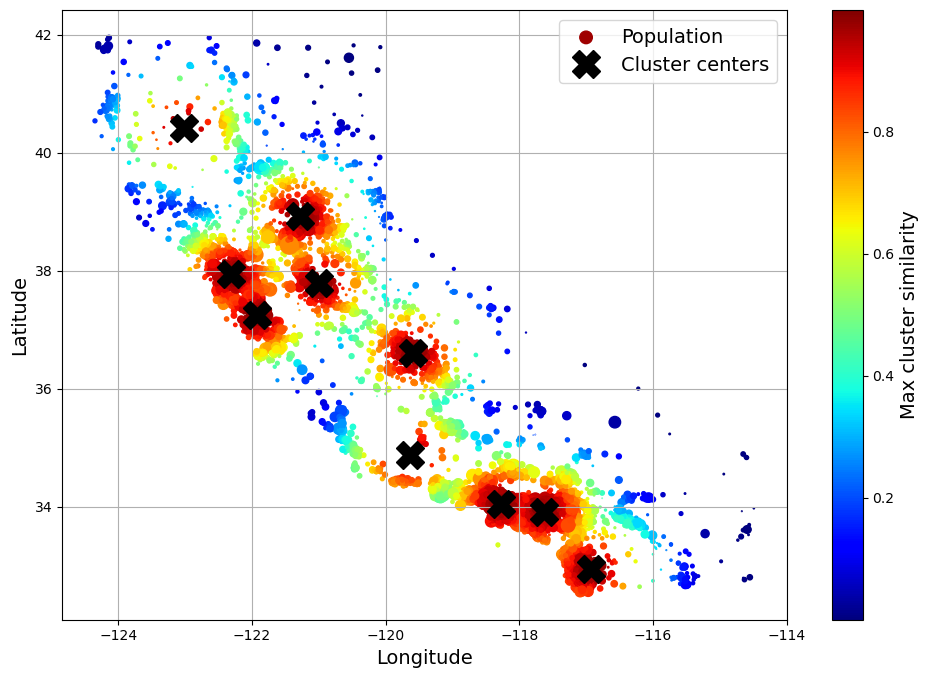

In [215]:

housing_renamed["Max cluster similarity"] = similarities.max(axis=1)

housing_renamed.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
                     s=housing_renamed["Population"] / 100, label="Population",
                     c="Max cluster similarity",
                     cmap="jet", colorbar=True,
                     legend=True, sharex=False, figsize=(10, 7))
plt.plot(cluster_simil.kmeans_.cluster_centers_[:, 1],
         cluster_simil.kmeans_.cluster_centers_[:, 0],
         linestyle="", color="black", marker="X", markersize=20,
         label="Cluster centers")
plt.legend(loc="upper right")
save_fig("district_cluster_plot")
plt.show()

## Tuberías de transformación (Pipelines)

Ahora construyamos una canalización para preprocesar los atributos numéricos:

In [218]:
from sklearn.pipeline import Pipeline


num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('impute', ...), ('standardize', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If

- Los nombres pueden ser cualquiera ('impute','standardize', etc.), siempre que sean únicos y no contengan guiones bajos dobles (__)

<code>  make_pipeline </code> sirve para no  nombrar los transformadores. 

In [221]:
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [222]:
from sklearn import set_config

set_config(display='diagram')

num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [223]:
housing_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292
...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455


In [224]:
housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared

array([[-1.42,  1.01,  1.86, ...,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, ..., -0.69, -0.37,  1.17],
       [-1.2 ,  1.28,  0.35, ..., -0.79, -0.78, -0.76],
       ...,
       [ 1.26, -1.43, -1.24, ...,  1.27,  0.68,  0.1 ],
       [ 0.59, -0.74,  0.67, ...,  0.27,  0.88,  0.15],
       [-1.42,  0.95,  1.23, ..., -0.68, -0.75, -0.31]])

In [225]:
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

<code> get_feature_names_out() </code> recuperar el nombre de las columnas

In [227]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns=num_pipeline.get_feature_names_out(),
    index=housing_num.index)
df_housing_num_prepared.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760709,-0.788768,-0.775727,-0.759789
14689,1.231216,-0.884924,-0.919891,0.702262,0.742306,0.383175,0.731375,-0.850281
20507,0.711362,-0.875549,0.589800,0.790125,1.595753,0.444376,1.755263,-0.180365


In [228]:
def monkey_patch_get_signature_names_out():
    """Monkey patch some classes which did not handle get_feature_names_out()
       correctly in Scikit-Learn 1.0.*."""
    from inspect import Signature, signature, Parameter
    import pandas as pd
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import make_pipeline, Pipeline
    from sklearn.preprocessing import FunctionTransformer, StandardScaler

    default_get_feature_names_out = StandardScaler.get_feature_names_out

    if not hasattr(SimpleImputer, "get_feature_names_out"):
      print("Monkey-patching SimpleImputer.get_feature_names_out()")
      SimpleImputer.get_feature_names_out = default_get_feature_names_out

    if not hasattr(FunctionTransformer, "get_feature_names_out"):
        print("Monkey-patching FunctionTransformer.get_feature_names_out()")
        orig_init = FunctionTransformer.__init__
        orig_sig = signature(orig_init)

        def __init__(*args, feature_names_out=None, **kwargs):
            orig_sig.bind(*args, **kwargs)
            orig_init(*args, **kwargs)
            args[0].feature_names_out = feature_names_out

        __init__.__signature__ = Signature(
            list(signature(orig_init).parameters.values()) + [
                Parameter("feature_names_out", Parameter.KEYWORD_ONLY)])

        def get_feature_names_out(self, names=None):
            if callable(self.feature_names_out):
                return self.feature_names_out(self, names)
            assert self.feature_names_out == "one-to-one"
            return default_get_feature_names_out(self, names)

        FunctionTransformer.__init__ = __init__
        FunctionTransformer.get_feature_names_out = get_feature_names_out

monkey_patch_get_signature_names_out()

#### Indexaciones

In [230]:
num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [231]:
num_pipeline[0] #primer estimador de canalización

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [232]:
num_pipeline[1] #segundo estimador de canalización

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [233]:
num_pipeline[:-1] #Contiene todos los estimadores, excepto el último

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has 

In [234]:
num_pipeline.steps #estimadores del pipeline

[('simpleimputer', SimpleImputer(strategy='median')),
 ('standardscaler', StandardScaler())]

In [235]:
num_pipeline.named_steps["simpleimputer"] #Nombre del estimador

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [236]:
num_pipeline.set_params(simpleimputer__strategy="median")

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

### ColumnTransformer 

In [238]:
from sklearn.compose import ColumnTransformer

num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

In [239]:
# Creación de un pipeline para preprocesar características categóricas.
cat_pipeline = make_pipeline(
    # El primer paso en el pipeline es un SimpleImputer, que se usa para manejar valores faltantes en las columnas categóricas.
    # - strategy="most_frequent": Imputa los valores faltantes con el valor más frecuente en cada columna.
    SimpleImputer(strategy="most_frequent"),

    # El siguiente paso es un OneHotEncoder, que convierte variables categóricas en variables binarias (one-hot encoding).
    # - handle_unknown="ignore": Si encuentra categorías desconocidas durante la transformación, las ignora (no lanza error).
    OneHotEncoder(handle_unknown="ignore")
)
cat_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('onehotencoder', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'most_frequent'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despit

In [240]:
# Se crea un ColumnTransformer para aplicar diferentes transformaciones a las columnas numéricas y categóricas de un conjunto de datos.
preprocessing = ColumnTransformer([
    # Primer paso: transformaciones para columnas numéricas
    # - "num": Este es el nombre de este paso en el ColumnTransformer.
    # - num_pipeline: El pipeline que se aplicará a las columnas numéricas (puede ser el pipeline de imputación, escalado, etc.).
    # - num_attribs: Las columnas numéricas que serán procesadas por el 'num_pipeline'.
    ("num", num_pipeline, num_attribs),

    # Segundo paso: transformaciones para columnas categóricas
    # - "cat": Este es el nombre del paso para las columnas categóricas.
    # - cat_pipeline: El pipeline que se aplicará a las columnas categóricas (en este caso, imputación y one-hot encoding).
    # - cat_attribs: Las columnas categóricas que serán procesadas por el 'cat_pipeline'.
    ("cat", cat_pipeline, cat_attribs),
])

# Al final, el objeto 'preprocessing' es un transformer compuesto que aplicará las transformaciones definidas
# (numericas y categóricas) a las columnas especificadas en los atributos 'num_attribs' y 'cat_attribs'.
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### make_column_transformer

In [242]:
# Se importa 'make_column_selector' y 'make_column_transformer' desde 'sklearn.compose'.
# - make_column_selector: Función para seleccionar columnas de un DataFrame según un criterio.
# - make_column_transformer: Función para crear un 'ColumnTransformer' que aplica transformaciones a las columnas seleccionadas.

from sklearn.compose import make_column_selector, make_column_transformer

# Crear un ColumnTransformer usando make_column_transformer
preprocessing = make_column_transformer(
    # Primer paso: aplicar 'num_pipeline' a las columnas numéricas
    # - make_column_selector(dtype_include=np.number): Selecciona todas las columnas con tipo de dato numérico (np.number).
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    
    # Segundo paso: aplicar 'cat_pipeline' a las columnas categóricas
    # - make_column_selector(dtype_include=object): Selecciona todas las columnas con tipo de dato categórico (objeto, generalmente cadenas).
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

# El objeto 'preprocessing' ahora es un transformer que aplica 'num_pipeline' a las columnas numéricas 
# y 'cat_pipeline' a las columnas categóricas de un DataFrame o matriz de entrada.
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline-1', ...), ('pipeline-2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

In [243]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared

array([[-1.42,  1.01,  1.86, ...,  0.  ,  1.  ,  0.  ],
       [ 0.6 , -0.7 ,  0.91, ...,  0.  ,  0.  ,  0.  ],
       [-1.2 ,  1.28,  0.35, ...,  0.  ,  0.  ,  0.  ],
       ...,
       [ 1.26, -1.43, -1.24, ...,  0.  ,  0.  ,  1.  ],
       [ 0.59, -0.74,  0.67, ...,  0.  ,  0.  ,  0.  ],
       [-1.42,  0.95,  1.23, ...,  0.  ,  0.  ,  1.  ]])

In [244]:
# extra code – shows that we can get a DataFrame out if we want
housing_prepared_fr = pd.DataFrame(
    housing_prepared,
    columns=preprocessing.get_feature_names_out(),
    index=housing.index)
housing_prepared_fr.head(2)

,pipeline-1__longitude,pipeline-1__latitude,pipeline-1__housing_median_age,pipeline-1__total_rooms,pipeline-1__total_bedrooms,pipeline-1__population,pipeline-1__households,pipeline-1__median_income,pipeline-2__ocean_proximity_<1H OCEAN,pipeline-2__ocean_proximity_INLAND,pipeline-2__ocean_proximity_ISLAND,pipeline-2__ocean_proximity_NEAR BAY,pipeline-2__ocean_proximity_NEAR OCEAN
13096,-1.423037,1.013606,1.861119,0.311912,1.368167,0.137460,1.394812,-0.936491,0.0,0.0,0.0,1.0,0.0
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435925,-0.693771,-0.373485,1.171942,1.0,0.0,0.0,0.0,0.0


In [245]:
# Definir una función que calcula el ratio (proporción) entre la primera y segunda columna de una matriz X.
# Esta función se aplicará dentro de un FunctionTransformer más adelante.
def column_ratio(X):
    # Devuelve el cociente entre la primera columna (X[:, [0]]) y la segunda columna (X[:, [1]]).
    return X[:, [0]] / X[:, [1]]

In [246]:
# Definir una función que asigna un nombre a la columna resultante de la transformación
# Esto es útil para asegurar que el nombre de la columna se mantenga consistente después de la transformación.
def ratio_name(function_transformer, feature_names_in):
    # El resultado de la transformación tendrá el nombre "ratio" para la columna generada.
    return ["ratio"]

In [247]:
# Crear un pipeline que incluye tres transformaciones:
# 1. Imputar valores faltantes usando la mediana.
# 2. Aplicar una transformación de columna para calcular un ratio.
# 3. Escalar los resultados con StandardScaler.
def ratio_pipeline():
    return make_pipeline(
        # Paso 1: SimpleImputer para manejar valores faltantes con la mediana
        SimpleImputer(strategy="median"),

        # Paso 2: FunctionTransformer para aplicar la función 'column_ratio' a los datos
        # feature_names_out=ratio_name asegura que la columna generada se llame "ratio"
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),

        # Paso 3: Estandarización de las características con StandardScaler
        StandardScaler()
    )

In [248]:
# Crear otro pipeline similar al anterior, pero para aplicar la transformación logarítmica
log_pipeline = make_pipeline(
    # Paso 1: SimpleImputer con mediana
    SimpleImputer(strategy="median"),

    # Paso 2: FunctionTransformer para aplicar logaritmo a las características
    FunctionTransformer(np.log, feature_names_out="one-to-one"),
    #"one-to-one" significa que cada columna de entrada tendrá exactamente una columna de salida con el mismo nombre.

    # Paso 3: Estandarización con StandardScaler
    StandardScaler()
)
log_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('functiontransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness de

In [249]:
# Crear una instancia del modelo ClusterSimilarity
# Este modelo calcula la similitud entre puntos geográficos basándose en su proximidad en los clusters.
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1., random_state=42)
cluster_simil 

,n_clusters,10
,gamma,1.0
,random_state,42


In [250]:
# Crear un pipeline predeterminado para columnas numéricas que maneja valores faltantes con la mediana y escala las columnas
default_num_pipeline = make_pipeline(
    # Imputar valores faltantes con la mediana
    SimpleImputer(strategy="median"),

    # Estandarizar las características numéricas con StandardScaler
    StandardScaler()
)
default_num_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('standardscaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

In [251]:

# Crear el ColumnTransformer para aplicar diferentes pipelines a las columnas seleccionadas
preprocessing = ColumnTransformer([
    # Primer paso: crear una nueva característica llamada "bedrooms" que es el ratio de total_bedrooms y total_rooms
    ("bedrooms", ratio_pipeline(), ["total_bedrooms", "total_rooms"]),
    
    # Segundo paso: crear una nueva característica "rooms_per_house" como el ratio entre total_rooms y households
    ("rooms_per_house", ratio_pipeline(), ["total_rooms", "households"]),
    
    # Tercer paso: "people_per_house", el ratio entre population y households
    ("people_per_house", ratio_pipeline(), ["population", "households"]),
    
    # Cuarto paso: aplicar un logaritmo a varias características y estandarizarlas
    ("log", log_pipeline, ["total_bedrooms", "total_rooms", "population", "households", "median_income"]),
    
    # Quinto paso: aplicar el modelo de similitud basado en los clusters geográficos para las coordenadas latitud y longitud
    ("geo", cluster_simil, ["latitude", "longitude"]),
    
    # Sexto paso: aplicar el pipeline de preprocesamiento de variables categóricas a las columnas de tipo objeto
    ("cat", cat_pipeline, make_column_selector(dtype_include=object)),
    
], 
# Resto de columnas (si las hubiera) serán procesadas con el pipeline numérico predeterminado
remainder=default_num_pipeline)  # Solo queda una columna restante: 'housing_median_age'
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``t

In [252]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 25)

In [253]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__income_cat'],
      dtype=object)

# Seleccionar y entrenar un modelo

## Entrenar y evaluar en el conjunto de entrenamiento

In [256]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: fl

In [257]:
lin_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: fl

Probemos el proceso de preprocesamiento completo en algunas instancias de entrenamiento:

In [259]:
# Usamos el modelo de regresión lineal previamente entrenado para hacer predicciones sobre el conjunto de datos 'housing'.
# 'lin_reg.predict(housing)' predice el valor objetivo (por ejemplo, el precio de una casa) para cada fila en el DataFrame 'housing'.
housing_predictions = lin_reg.predict(housing)

# Mostramos las primeras 5 predicciones, redondeadas al valor más cercano de los cien más cercano.
# '.round(-2)' redondea los valores de las predicciones al número más cercano con dos ceros (es decir, a la centena).
# Esto puede ser útil para presentar las predicciones de una manera más legible.
housing_predictions[:5].round(-2)  # -2 = rounded to the nearest hundred

array([247100., 397600., 119400.,  95500., 326800.])

Comparar con los valores reales:

In [261]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

In [262]:
# Este bloque de código calcula las razones de error (error ratios) como se describió en el libro.
# La fórmula general para la razón de error es: (predicción / valor real) - 1.
# Es decir, se compara el porcentaje de error entre las predicciones y los valores reales.

# 1. Tomamos las primeras 5 predicciones y las redondeamos a las centenas.
# housing_predictions[:5] toma las primeras 5 predicciones.
# .round(-2) redondea esas predicciones al número más cercano en las centenas.
error_ratios = housing_predictions[:5].round(-2) / housing_labels.iloc[:5].values - 1

# 2. Convertimos las razones de error en porcentajes y las formateamos como cadenas.
# Usamos f-string para imprimir cada razón de error multiplicada por 100 y con un decimal.
# 100 * ratio convierte la razón de error en porcentaje, y luego lo mostramos como un número con un solo decimal.
print(", ".join([f"{100 * ratio:.1f}%" for ratio in error_ratios]))

-46.1%, -17.8%, 17.4%, -0.6%, -9.7%


**Advertencia**: En versiones recientes de Scikit-Learn, debe usar `root_mean_squared_error(labels, predictions)` para calcular el RMSE, en lugar de `mean_squared_error(labels, predictions, squared=False)`. El siguiente bloque `try`/`except` intenta importar `root_mean_squared_error` y, si falla, simplemente lo define.

In [264]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

68004.5246946409

In [265]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
tree_reg

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

In [266]:
tree_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

In [267]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = root_mean_squared_error(housing_labels, housing_predictions)
tree_rmse

0.0

## Validación cruzada (Cross-Validation)

In [269]:
tree_reg

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

In [270]:
# Importar la función 'cross_val_score' desde sklearn.model_selection para realizar validación cruzada.
from sklearn.model_selection import cross_val_score

# Realizamos la validación cruzada con el modelo 'tree_reg' y calculamos el RMSE (Root Mean Squared Error).
# - scoring="neg_root_mean_squared_error" indica que queremos evaluar el modelo usando RMSE, pero en formato negativo.
# - cv=10 indica que usamos 10 pliegues en la validación cruzada (10 iteraciones).
# 'cross_val_score' devuelve valores negativos de RMSE porque esta métrica se debe minimizar, pero la función se basa en maximizar la métrica.
# Por esta razón, agregamos el signo negativo delante de 'cross_val_score' para convertir esos valores negativos en positivos.
tree_rmses = -cross_val_score(
    tree_reg,                # El modelo de regresión que estamos evaluando.
    housing,                 # El conjunto de datos con las características 
    housing_labels,          # Las etiquetas de salida 
    scoring="neg_root_mean_squared_error",  # Queremos evaluar usando RMSE, pero los valores son devueltos como negativos.
    cv=10                    # Número de pliegues de la validación cruzada (10 pliegues en este caso).
)

# Al aplicar el signo negativo ('-'), estamos invirtiendo los valores negativos que 'cross_val_score' devuelve por defecto para las métricas de minimización.
# Esto convierte los valores de RMSE en positivos, lo cual es más intuitivo, ya que queremos que el RMSE sea lo más bajo posible (cerca de 0).

In [271]:
tree_rmses

array([66809.37, 63504.01, 66157.31, 65439.35, 65505.98, 66966.56,
       68845.29, 69368.09, 70322.61, 65371.35])

In [272]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     66828.991942
std       2109.500358
min      63504.013557
25%      65456.007554
50%      66483.337336
75%      68375.606282
max      70322.608451
dtype: float64

In [273]:
lin_reg

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: fl

In [274]:
# extra code – computes the error stats for the linear model
lin_rmses = -cross_val_score(lin_reg, housing, housing_labels,
                              scoring="neg_root_mean_squared_error", cv=10)
pd.Series(lin_rmses).describe()

count       10.000000
mean     69092.200605
std       3689.500079
min      65042.044581
25%      67538.125253
50%      68279.448225
75%      69282.105447
max      78664.312855
dtype: float64

**Advertencia:** la siguiente celda puede tardar unos minutos en ejecutarse:

In [276]:
# Importamos el modelo de RandomForestRegressor desde sklearn.ensemble.
# Este modelo es un regressor basado en un conjunto de árboles de decisión (Random Forest).
from sklearn.ensemble import RandomForestRegressor

# Crear un pipeline llamado 'forest_reg' que primero aplica el preprocesamiento
# (definido previamente en la variable 'preprocessing'), y luego utiliza el modelo
# RandomForestRegressor para hacer predicciones en el conjunto de datos.
# El modelo RandomForestRegressor es un ensemble (conjunto) de árboles de decisión.
# 'random_state=42' asegura que los resultados sean reproducibles (es decir, que el modelo
# produzca los mismos resultados si se ejecuta nuevamente con los mismos datos).
forest_reg = make_pipeline(
    preprocessing,  # Aplica las transformaciones previas definidas en 'preprocessing'
    RandomForestRegressor(random_state=42)  # Utiliza el modelo RandomForestRegressor
)
forest_reg 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshol

In [277]:
# Evaluamos el modelo 'forest_reg' usando validación cruzada con 10 pliegues (cv=10).
# 'cross_val_score' calcula el desempeño del modelo en función del RMSE (Root Mean Squared Error).
# 'scoring="neg_root_mean_squared_error"' le dice a cross_val_score que calcule el RMSE como métrica,
# pero dado que RMSE es una métrica que se debe minimizar, se devuelve un valor negativo.
# Al colocar el signo negativo antes de 'cross_val_score', convertimos estos valores negativos en positivos.
forest_rmses = -cross_val_score(
    forest_reg,  # El modelo de RandomForestRegressor dentro del pipeline
    housing,  # El conjunto de datos de entrada
    housing_labels,  # Las etiquetas o valores reales que estamos tratando de predecir
    scoring="neg_root_mean_squared_error",  # La métrica a evaluar, en este caso el RMSE
    cv=10  # Número de pliegues para la validación cruzada (10 en este caso)
)

In [278]:
pd.Series(forest_rmses).describe()

count       10.000000
mean     47007.661117
std       1071.885942
min      45438.898450
25%      46378.232205
50%      47090.462095
75%      47406.931316
max      49311.141107
dtype: float64

Comparemos este RMSE medido mediante validación cruzada (el "error de validación") con el RMSE medido en el conjunto de entrenamiento (el "error de entrenamiento"):

In [280]:
forest_reg.fit(housing, housing_labels)
housing_predictions = forest_reg.predict(housing)
forest_rmse = root_mean_squared_error(housing_labels, housing_predictions)
forest_rmse

17552.468630800544

El error de entrenamiento es mucho menor que el error de validación, lo que suele indicar que el modelo se ha sobreajustado al conjunto de entrenamiento. Otra posible explicación podría ser que exista una discrepancia entre los datos de entrenamiento y los de validación, pero no es el caso en este caso, ya que ambos provienen del mismo conjunto de datos que mezclamos y dividimos en dos partes.

# Fine-Tune Your Model

## Grid Search

**Advertencia:** la siguiente celda puede tardar unos minutos en ejecutarse:

In [285]:
# Importar la clase GridSearchCV desde sklearn.model_selection.
# GridSearchCV se usa para encontrar la mejor combinación de hiperparámetros en un modelo, 
#probando todas las combinaciones posibles en una rejilla de parámetros especificada.
from sklearn.model_selection import GridSearchCV

# Crear un pipeline completo llamado 'full_pipeline' que incluye dos pasos:
# 1. 'preprocessing': Las transformaciones de preprocesamiento definidas en el pipeline previamente.
# 2. 'random_forest': El modelo RandomForestRegressor que será entrenado sobre los datos preprocesados.
# Este pipeline aplica primero las transformaciones y luego entrena el modelo en el conjunto de datos preprocesados.
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),  # Paso de preprocesamiento (aplicando las transformaciones definidas previamente)
    ("random_forest", RandomForestRegressor(random_state=42)),  # Paso de modelo: RandomForestRegressor
])

full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, de

In [286]:
preprocessing.get_feature_names_out()

array(['bedrooms__ratio', 'rooms_per_house__ratio',
       'people_per_house__ratio', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__Cluster 0 similarity',
       'geo__Cluster 1 similarity', 'geo__Cluster 2 similarity',
       'geo__Cluster 3 similarity', 'geo__Cluster 4 similarity',
       'geo__Cluster 5 similarity', 'geo__Cluster 6 similarity',
       'geo__Cluster 7 similarity', 'geo__Cluster 8 similarity',
       'geo__Cluster 9 similarity', 'cat__ocean_proximity_<1H OCEAN',
       'cat__ocean_proximity_INLAND', 'cat__ocean_proximity_ISLAND',
       'cat__ocean_proximity_NEAR BAY', 'cat__ocean_proximity_NEAR OCEAN',
       'remainder__housing_median_age', 'remainder__income_cat'],
      dtype=object)

In [287]:
# Definir una rejilla de parámetros ('param_grid') para la búsqueda en la cuadrícula.
# Esta rejilla contiene las combinaciones de parámetros que queremos que GridSearchCV pruebe.
param_grid = [
    # Primer conjunto de combinaciones de hiperparámetros a probar
    {'preprocessing__geo__n_clusters': [5, 8, 10],  # Número de clusters para el modelo 'geo' en el preprocesamiento
     'random_forest__max_features': [4, 6, 8]},  # Número de características a considerar en cada división del árbol

    # Segundo conjunto de combinaciones de hiperparámetros a probar
    {'preprocessing__geo__n_clusters': [10, 15],  # Prueba con un rango diferente de valores para los clusters
     'random_forest__max_features': [6, 8, 10]},  # Cambiar el número de características consideradas en cada división
]

param_grid 

[{'preprocessing__geo__n_clusters': [5, 8, 10],
  'random_forest__max_features': [4, 6, 8]},
 {'preprocessing__geo__n_clusters': [10, 15],
  'random_forest__max_features': [6, 8, 10]}]

La búsqueda en cuadrícula explorará $15$ combinaciones de valores de hiperparámetros y entrenará la canalización $3$ veces por combincación, ya que utilizamos una validación cruzada triple

In [289]:
preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``t

Se puede hacer referencia a cualquier estimador de una canalización, incluso si este estimadior está anidado en varias canalizaciones y transformadores de columnas.
Ejemplo  <code> preprocessing__geo__n_clusters </code>:

1. Divide la cadena en los guiones bajos dobles.
2. Busca un estimador nombrado <code> preprocessing </code> en la canalización y encuentra el preprocesamiento *ColumnTransformer*
3. Busca un transformador llamado <code> geo </code>
4. Encuentra <code> n_clusters </code> (el hiperparametro de este transformador

In [291]:
# Crear una instancia de GridSearchCV con el pipeline 'full_pipeline' y la rejilla de parámetros 'param_grid'.
# GridSearchCV prueba todas las combinaciones posibles de los parámetros definidos en 'param_grid' con validación cruzada.
# 'cv=3' indica que la validación cruzada se realiza con 3 pliegues.
# 'scoring="neg_root_mean_squared_error"' indica que se utilizará RMSE negativo como métrica para evaluar el rendimiento.
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')

# Entrenamos el modelo usando la búsqueda en la cuadrícula.
# Esto probará todas las combinaciones de parámetros y seleccionará la mejor basada en el rendimiento.
grid_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity

Puede obtener la lista completa de hiperparámetros disponibles para ajustar consultando `full_pipeline.get_params().keys()`:

In [293]:
# extra code – shows part of the output of get_params().keys()
print(str(full_pipeline.get_params().keys())[:1000] + "...")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__force_int_remainder_cols', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__transform_input', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 

La mejor combinación de hiperparámetros encontrada:

In [295]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [296]:
grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, de

si <code> grid_search </code> se inicializa con <code> refit=True </code>, una vez que encuentra el mejor esrimador mediante validación cruzada, lo reentrena con todo el conjunto de entrenamiento.

Veamos la puntuación de cada combinación de hiperparámetros probada durante la búsqueda en la cuadrícula:

In [299]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)

# extra code – these few lines of code just make the DataFrame look nicer
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
score_cols = ["split0", "split1", "split2", "mean_test_rmse"]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)

cv_res

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
12,15,6,44197,44705,45422,44775
13,15,8,44756,44952,45660,45123
14,15,10,45302,45113,45943,45453
7,10,6,45306,45748,46694,45916
9,10,6,45306,45748,46694,45916
6,10,4,45389,45642,47119,46050
8,10,8,45806,46155,46877,46279
10,10,8,45806,46155,46877,46279
4,8,6,46129,46065,46996,46397
3,8,4,46231,45955,47069,46418


## Randomized Search

In [301]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

Pruebe 30 (`n_iter` × `cv`) combinaciones aleatorias de hiperparámetros:

**Advertencia:** la siguiente celda puede tardar unos minutos en ejecutarse:

In [304]:
# Importar la clase RandomizedSearchCV desde sklearn.model_selection.
# RandomizedSearchCV es similar a GridSearchCV, pero en lugar de probar todas las combinaciones posibles,
# prueba un número aleatorio de combinaciones de los hiperparámetros definidos, lo que puede ahorrar tiempo.
from sklearn.model_selection import RandomizedSearchCV

# Importar 'randint' de scipy.stats para generar distribuciones de enteros aleatorios.
# Se usará para definir rangos de parámetros aleatorios para la búsqueda.
from scipy.stats import randint

# Definir las distribuciones de parámetros que RandomizedSearchCV probará aleatoriamente.
# 'randint(low, high)' genera números enteros aleatorios dentro de un rango definido por 'low' y 'high'.
# 'preprocessing__geo__n_clusters' define el rango de valores posibles para el número de clusters en el preprocesamiento geo.
# 'random_forest__max_features' define el rango de valores posibles para el número de características a considerar en cada división del árbol.
param_distribs = {
    'preprocessing__geo__n_clusters': randint(low=3, high=50),  # Rango de valores aleatorios entre 3 y 50 para 'n_clusters'
    'random_forest__max_features': randint(low=2, high=20)      # Rango de valores aleatorios entre 2 y 20 para 'max_features'
}


In [305]:
random_number = randint(3,50)
print(random_number.rvs())

28


In [306]:
param_distribs

{'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x1f0e920f020>,
 'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x1f0e920d4c0>}

In [307]:

# Crear una instancia de RandomizedSearchCV.
# RandomizedSearchCV realizará una búsqueda aleatoria de 10 combinaciones de parámetros aleatorios 
# (n_iter=10) utilizando validación cruzada con 3 pliegues (cv=3).
# 'scoring="neg_root_mean_squared_error"' especifica que el modelo se evaluará en base a RMSE negativo (buscando minimizar el error).
# 'random_state=42' asegura que la búsqueda aleatoria sea reproducible.
rnd_search = RandomizedSearchCV(
    full_pipeline,                  # El pipeline completo que incluye tanto el preprocesamiento como el modelo.
    param_distributions=param_distribs,  # Las distribuciones de parámetros aleatorios a probar.
    n_iter=10,                      # El número de combinaciones aleatorias de parámetros a probar (10 combinaciones en este caso).
    cv=3,                           # Número de pliegues de la validación cruzada (3 pliegues en este caso).
    scoring='neg_root_mean_squared_error',  # Métrica para evaluar el rendimiento del modelo: RMSE negativo.
    random_state=42,                 # Fijar la semilla para garantizar que los resultados sean reproducibles.
    verbose=1
)

# Entrenar el modelo utilizando la búsqueda aleatoria de parámetros.
# 'rnd_search.fit()' ejecutará la búsqueda aleatoria probando 10 combinaciones de parámetros aleatorios 
# y seleccionando la mejor combinación según el RMSE negativo en la validación cruzada.
rnd_search.fit(housing, housing_labels)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....001F0E920F020>, 'random_forest__max_features': <scipy.stats....001F0E920D4C0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies th

In [308]:
print(type(rnd_search))

<class 'sklearn.model_selection._search.RandomizedSearchCV'>


In [309]:
print(hasattr(rnd_search, 'cv_results_'))

True


In [310]:
# extra code – displays the random search results
cv_res = pd.DataFrame(rnd_search.cv_results_)
cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_res = cv_res[["param_preprocessing__geo__n_clusters",
                 "param_random_forest__max_features", "split0_test_score",
                 "split1_test_score", "split2_test_score", "mean_test_score"]]
cv_res.columns = ["n_clusters", "max_features"] + score_cols
cv_res[score_cols] = -cv_res[score_cols].round().astype(np.int64)
cv_res.head()

,n_clusters,max_features,split0,split1,split2,mean_test_rmse
1,45,9,41682,42825,43219,42575
5,42,4,41947,42788,43830,42855
8,32,7,42333,43057,43695,43028
0,41,16,43245,43497,44290,43677
2,23,8,43188,43795,44556,43846


**Sección adicional: cómo elegir la distribución de muestreo para un hiperparámetro**

* `scipy.stats.randint(a, b+1)`: para hiperparámetros con valores _discretos_ que van de a a b, y todos los valores en ese rango parecen igualmente probables.
* `scipy.stats.uniform(a, b)`: muy similar, pero para hiperparámetros _continuos_.
* `scipy.stats.geom(1 / scale)`: para valores discretos, cuando se desea muestrear aproximadamente en una escala dada. Por ejemplo, con scale=1000, la mayoría de las muestras estarán en este rango, pero aproximadamente el 10% de todas las muestras serán <100 y aproximadamente el 10% serán >2300.
* `scipy.stats.expon(scale)`: este es el equivalente continuo de `geom`. Simplemente configure `scale` con el valor más probable. * `scipy.stats.loguniform(a, b)`: cuando prácticamente no se tiene idea de la escala óptima del hiperparámetro. Si se establece a = 0,01 y b = 100, es tan probable muestrear un valor entre 0,01 y 0,1 como uno entre 10 y 100.

Aquí se muestran gráficos de las funciones de masa de probabilidad (para variables discretas) y funciones de densidad de probabilidad (para variables continuas) para `randint()`, `uniform()`, `geom()` y `expon()`:

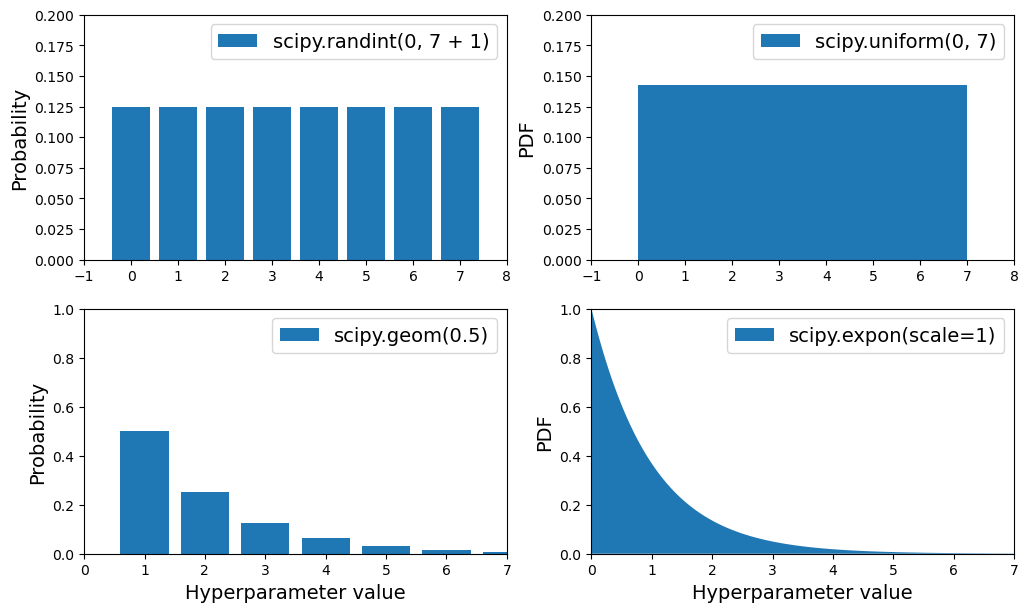

In [313]:
# extra code – plots a few distributions you can use in randomized search

from scipy.stats import randint, uniform, geom, expon

xs1 = np.arange(0, 7 + 1)
randint_distrib = randint(0, 7 + 1).pmf(xs1)

xs2 = np.linspace(0, 7, 500)
uniform_distrib = uniform(0, 7).pdf(xs2)

xs3 = np.arange(0, 7 + 1)
geom_distrib = geom(0.5).pmf(xs3)

xs4 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.bar(xs1, randint_distrib, label="scipy.randint(0, 7 + 1)")
plt.ylabel("Probability")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 2)
plt.fill_between(xs2, uniform_distrib, label="scipy.uniform(0, 7)")
plt.ylabel("PDF")
plt.legend()
plt.axis([-1, 8, 0, 0.2])

plt.subplot(2, 2, 3)
plt.bar(xs3, geom_distrib, label="scipy.geom(0.5)")
plt.xlabel("Hyperparameter value")
plt.ylabel("Probability")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 4)
plt.fill_between(xs4, expon_distrib, label="scipy.expon(scale=1)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.show()

Aquí se muestran las PDF de `expon()` y `loguniform()` (columna izquierda), así como la PDF de log(X) (columna derecha). La columna derecha muestra la distribución de las escalas de los hiperparámetros. Se puede observar que `expon()` favorece los hiperparámetros con una escala aproximada a la deseada, con una cola más larga hacia las escalas más pequeñas. Sin embargo, `loguniform()` no favorece ninguna escala; todas son igualmente probables:

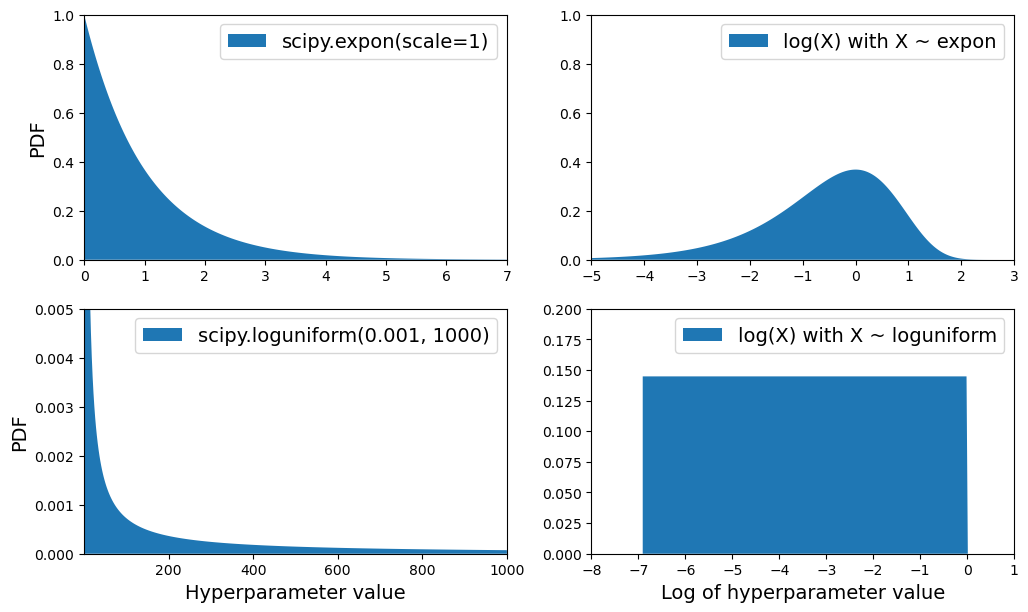

In [315]:
# extra code – shows the difference between expon and loguniform

from scipy.stats import loguniform

xs1 = np.linspace(0, 7, 500)
expon_distrib = expon(scale=1).pdf(xs1)

log_xs2 = np.linspace(-5, 3, 500)
log_expon_distrib = np.exp(log_xs2 - np.exp(log_xs2))

xs3 = np.linspace(0.001, 1000, 500)
loguniform_distrib = loguniform(0.001, 1000).pdf(xs3)

log_xs4 = np.linspace(np.log(0.001), np.log(1000), 500)
log_loguniform_distrib = uniform(np.log(0.001), np.log(1000)).pdf(log_xs4)

plt.figure(figsize=(12, 7))

plt.subplot(2, 2, 1)
plt.fill_between(xs1, expon_distrib,
                 label="scipy.expon(scale=1)")
plt.ylabel("PDF")
plt.legend()
plt.axis([0, 7, 0, 1])

plt.subplot(2, 2, 2)
plt.fill_between(log_xs2, log_expon_distrib,
                 label="log(X) with X ~ expon")
plt.legend()
plt.axis([-5, 3, 0, 1])

plt.subplot(2, 2, 3)
plt.fill_between(xs3, loguniform_distrib,
                 label="scipy.loguniform(0.001, 1000)")
plt.xlabel("Hyperparameter value")
plt.ylabel("PDF")
plt.legend()
plt.axis([0.001, 1000, 0, 0.005])

plt.subplot(2, 2, 4)
plt.fill_between(log_xs4, log_loguniform_distrib,
                 label="log(X) with X ~ loguniform")
plt.xlabel("Log of hyperparameter value")
plt.legend()
plt.axis([-8, 1, 0, 0.2])

plt.show()

## Analizar los mejores modelos y sus errores.

<code> RandomForestReggressor </code> puede indicar la importancia relativa de cada atributo para realizar precisiones precisas. Esto lo hace con 
<code> feature_importances_ </code>

In [318]:
final_model = rnd_search.best_estimator_  # includes preprocessing
feature_importances = final_model["random_forest"].feature_importances_
feature_importances.round(2)

array([0.05, 0.04, 0.05, 0.01, 0.01, 0.01, 0.01, 0.16, 0.01, 0.01, 0.01,
       0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.  ,
       0.01, 0.  , 0.01, 0.03, 0.02, 0.  , 0.01, 0.01, 0.02, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.02, 0.  , 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.06,
       0.  , 0.  , 0.  , 0.01, 0.12])

Ordenaremos estos puntajes de importancia en orden descendente y los mostraremos junto a sus nombres de atribustos correspondientes.

In [320]:
sorted(zip(feature_importances,
           final_model["preprocessing"].get_feature_names_out()),
           reverse=True)

[(0.16456260553039748, 'log__median_income'),
 (0.12264887480440562, 'remainder__income_cat'),
 (0.06144960021760335, 'cat__ocean_proximity_INLAND'),
 (0.05347502186039226, 'people_per_house__ratio'),
 (0.04783751917440328, 'bedrooms__ratio'),
 (0.04034228472380742, 'rooms_per_house__ratio'),
 (0.03711045390491348, 'geo__Cluster 3 similarity'),
 (0.028445462501172258, 'geo__Cluster 17 similarity'),
 (0.020716125281811156, 'geo__Cluster 6 similarity'),
 (0.018654183544598312, 'geo__Cluster 22 similarity'),
 (0.017217733239885416, 'geo__Cluster 32 similarity'),
 (0.015110660965319864, 'geo__Cluster 18 similarity'),
 (0.0142818282020754, 'geo__Cluster 41 similarity'),
 (0.013328388398764901, 'geo__Cluster 7 similarity'),
 (0.013214370003209028, 'geo__Cluster 43 similarity'),
 (0.012941557652072423, 'geo__Cluster 26 similarity'),
 (0.012566449621777647, 'remainder__housing_median_age'),
 (0.01207497972784075, 'geo__Cluster 2 similarity'),
 (0.011106515090172313, 'geo__Cluster 34 similarity

De lo anterior se puede observar que la categoría <code>  ocean_proximity </code> es realmente útil, por lo que podrías intentar eliminar las demás.

El transformador <code>  from sklearn.feature_selection import SelectFromModel </code> puede descartar automáticamente las características menos útiles

## Evalúe su sistema en el conjunto de pruebas

In [324]:
# Eliminamos la columna "median_house_value" de X_test (conjunto de características), ya que solo necesitamos las características para hacer predicciones.
X_test = strat_test_set.drop("median_house_value", axis=1)

# Creamos la variable objetivo (y_test), que es la columna "median_house_value" de nuestro conjunto de prueba.
y_test = strat_test_set["median_house_value"].copy()

# Usamos el modelo final entrenado para hacer predicciones en el conjunto de prueba X_test.
final_predictions = final_model.predict(X_test)

# Calculamos el Error Cuadrático Medio (RMSE) entre las predicciones y los valores reales de y_test.
final_rmse = root_mean_squared_error(y_test, final_predictions)

# Imprimimos el RMSE para evaluar el rendimiento del modelo.
print(final_rmse)

41920.34240458236


Podemos calcular un intervalo de confianza del 95% para el RMSE de prueba:

In [326]:
from scipy import stats
import numpy as np

# Función para calcular el RMSE (Root Mean Squared Error) a partir de los errores cuadráticos
def rmse(squared_errors):
    # Devuelve la raíz cuadrada de la media de los errores cuadráticos
    return np.sqrt(np.mean(squared_errors))

# Nivel de confianza para el intervalo de confianza (en este caso, 95%)
confidence = 0.95

# Calculamos los errores cuadráticos (squared errors) entre las predicciones y los valores reales
squared_errors = (final_predictions - y_test) ** 2

# Aplicamos el bootstrap a los errores cuadráticos para calcular el intervalo de confianza del RMSE
# stats.bootstrap realiza el muestreo con reemplazo, pasando la función rmse para calcular el RMSE
boot_result = stats.bootstrap([squared_errors], rmse,
                              confidence_level=confidence, random_state=42)

# Extraemos el intervalo de confianza (límites inferior y superior) del RMSE
rmse_lower, rmse_upper = boot_result.confidence_interval

# Mostramos los límites del intervalo de confianza del RMSE
print(f"Intervalo de confianza del RMSE al {confidence*100}%: ({rmse_lower}, {rmse_upper})")

Intervalo de confianza del RMSE al 95.0%: (40012.37071213927, 44193.9610781433)


In [327]:
rmse_lower, rmse_upper

(40012.37071213927, 44193.9610781433)

## Persistencia del modelo usando joblib

Guardar el modelo final:

In [330]:
import joblib

joblib.dump(final_model, "my_california_housing_model.pkl")

['my_california_housing_model.pkl']

Suele ser recomendable:
- Guardar todos los modelos con los que se experimenta para poder volver fácilmente a cualquier modelo que se desee.
- Guardar las puntuaciones de validación cruzada y, quizás, las predicciones reales en el conjunto de validación. 

Ahora puede implementar este modelo en producción. Por ejemplo, el siguiente código podría ser un script que se ejecutaría en producción:

In [333]:
# Importa el módulo joblib para cargar modelos entrenados previamente desde un archivo.
import joblib

# Importa otras librerías necesarias (esto está excluido para la concisión)
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics.pairwise import rbf_kernel

# Definimos una función personalizada para calcular el ratio entre las dos primeras columnas de los datos (ejemplo de transformación de columnas)
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]  # Devuelve la relación entre la primera y segunda columna de los datos
    # X[:, [0]] y X[:, [1]] seleccionan las dos primeras columnas, y la división entre ellas produce el ratio

# La clase ClusterSimilarity está comentada. Este tipo de clases puede usarse para realizar transformaciones personalizadas.
# Aquí, se podría definir alguna lógica para crear una clase que derive de BaseEstimator y TransformerMixin, que permita 
# realizar transformaciones adicionales sobre los datos (esto podría incluir técnicas de agrupamiento, por ejemplo).
#class ClusterSimilarity(BaseEstimator, TransformerMixin):
#    [...]

# Aquí se carga el modelo previamente guardado (por ejemplo, un modelo entrenado de California Housing en un archivo .pkl).
final_model_reloaded = joblib.load("my_california_housing_model.pkl")
final_model_reloaded

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, de

In [334]:
# 'housing' es el conjunto de datos original. Aquí seleccionamos las primeras 5 filas como si fueran nuevos datos (nuevos distritos)
new_data = housing.iloc[:5]  # Se asume que `housing` es un DataFrame de pandas con datos de ejemplo.

# Utilizamos el modelo cargado (`final_model_reloaded`) para hacer predicciones sobre los nuevos datos (nuevos distritos).
predictions = final_model_reloaded.predict(new_data)

# Las predicciones resultantes son los valores predichos (por ejemplo, precios de viviendas) para los primeros 5 distritos.

In [335]:
predictions

array([432399.14, 452785.06, 107790.  ,  97622.  , 349001.06])

Podrías usar pickle en su lugar, pero joblib es más eficiente.

# Exercise solutions

## 1.

Ejercicio: _Pruebe un regresor de Máquina de Vectores de Soporte (`sklearn.svm.SVR`) con varios hiperparámetros, como `kernel="linear"` (con varios valores para el hiperparámetro `C`) o `kernel="rbf"` (con varios valores para los hiperparámetros `C` y `gamma`). Tenga en cuenta que las Máquinas de Vectores de Soporte (SVM) no escalan bien a conjuntos de datos grandes, por lo que probablemente debería entrenar su modelo solo con las primeras 5000 instancias del conjunto de entrenamiento y usar solo una validación cruzada triple; de ​​lo contrario, tardará horas. No se preocupe por el significado de los hiperparámetros por ahora (consulte el cuaderno de SVM si le interesa). ¿Cuál es el rendimiento del mejor predictor `SVR`?_

In [340]:
# Importamos las librerías necesarias:
# GridSearchCV para realizar búsqueda en cuadrícula (grid search) y SVR para el modelo de regresión con soporte vectorial.
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Definimos un diccionario de parámetros que se van a explorar durante la búsqueda en cuadrícula.
param_grid = [
        # Primer conjunto de parámetros: 'kernel' lineal
        {'svr__kernel': ['linear'],  # Exploramos el kernel lineal
         'svr__C': [10., 30., 100., 300., 1000., 3000., 10000., 30000.0]},  # Exploramos diferentes valores de C (parámetro de regularización)

        # Segundo conjunto de parámetros: 'kernel' radial basis function (RBF)
        {'svr__kernel': ['rbf'],  # Exploramos el kernel RBF
         'svr__C': [1.0, 3.0, 10., 30., 100., 300., 1000.0],  # Exploramos diferentes valores de C para el kernel RBF
         'svr__gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},  # Exploramos diferentes valores de gamma, que controla la amplitud de la función RBF
    ]

# Se crea un pipeline que contiene dos pasos:
# 1. "preprocessing": Este paso aplicará alguna transformación a los datos antes de que se entrene el modelo.
# 2. "svr": Este es el modelo de soporte vectorial de regresión (SVR) que vamos a entrenar.
svr_pipeline = Pipeline([("preprocessing", preprocessing), ("svr", SVR())])

# Creamos un objeto de GridSearchCV que va a buscar el mejor conjunto de parámetros para el modelo.
# Le pasamos el pipeline, el grid de parámetros a explorar (param_grid), y otras configuraciones:
# cv=3: Usamos 3 particiones para la validación cruzada.
# scoring='neg_root_mean_squared_error': Queremos maximizar la puntuación usando el RMSE negativo (es negativo porque GridSearchCV busca maximizar la puntuación).
grid_search = GridSearchCV(svr_pipeline, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error')

# Finalmente, entrenamos el modelo usando un subconjunto de los datos (en este caso, las primeras 5000 muestras de housing y housing_labels).
grid_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'svr__C': [10.0, 30.0, ...], 'svr__kernel': ['linear']}, {'svr__C': [1.0, 3.0, ...], 'svr__gamma': [0.01, 0.03, ...], 'svr__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 

El mejor modelo logra la siguiente puntuación (evaluada mediante validación cruzada triple):

In [598]:
# El mejor puntaje obtenido en la búsqueda en cuadrícula es almacenado en grid_search.best_score_.
# Dado que usamos 'neg_root_mean_squared_error' como métrica de evaluación,
# este puntaje es negativo porque 'GridSearchCV' minimiza la métrica (el error).
# Por lo tanto, debemos convertirlo en positivo para obtener el RMSE real.
svr_grid_search_rmse = -grid_search.best_score_

# Imprimimos el RMSE real obtenido, que es el mejor RMSE encontrado durante la búsqueda en cuadrícula.
svr_grid_search_rmse

69132.80103940469

Esto es mucho peor que el `RandomForestRegressor` (aunque, para ser justos, entrenamos el modelo con muchos menos datos). Revisemos los mejores hiperparámetros encontrados:

In [344]:
grid_search.best_params_

{'svr__C': 10000.0, 'svr__kernel': 'linear'}

El kernel lineal parece mejor que el kernel RBF. Observe que el valor de `C` es el máximo probado. En este caso, es fundamental reiniciar la búsqueda en la cuadrícula con valores más altos para `C` (eliminando los valores más bajos), ya que es probable que valores más altos de `C` sean mejores.

## 2.

Ejercicio: _Intente reemplazar `GridSearchCV` con un `RandomizedSearchCV`._

**Advertencia:** La siguiente celda tardará varios minutos en ejecutarse. Puede especificar `verbose=2` al crear `RandomizedSearchCV` si desea ver los detalles del entrenamiento.

In [603]:
# Importamos las librerías necesarias:
# RandomizedSearchCV para búsqueda aleatoria de hiperparámetros y funciones estadísticas como expon y loguniform.
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, loguniform

# Nota: `gamma` se ignora cuando el kernel es "linear", por lo que en este caso no será utilizado para el kernel lineal.
# Las distribuciones que se usan para realizar la búsqueda aleatoria de hiperparámetros:
param_distribs = {
        # Kernel que se probará: "linear" y "rbf"
        'svr__kernel': ['linear', 'rbf'],
        
        # Parámetro 'C' que controla la regularización, probando valores de 'C' distribuidos de forma logarítmica
        # El parámetro loguniform(20, 200_000) generará números distribuidos uniformemente en el espacio logarítmico entre 20 y 200,000
        'svr__C': loguniform(20, 200_000),
        
        # Parámetro 'gamma', utilizado solo cuando el kernel es "rbf". La distribución exponencial se usará para buscar valores de gamma.
        'svr__gamma': expon(scale=1.0),  # Escala=1.0 es un valor común, pero puede ajustarse según sea necesario.
    }

# Creamos un objeto de RandomizedSearchCV, que realiza búsqueda aleatoria sobre el conjunto de hiperparámetros.
# Le pasamos el pipeline (svr_pipeline), las distribuciones de parámetros a probar, el número de iteraciones (n_iter=50),
# y la validación cruzada (cv=3).
rnd_search = RandomizedSearchCV(svr_pipeline,
                                param_distributions=param_distribs,  # Definimos las distribuciones de los parámetros
                                n_iter=50,  # Número de combinaciones aleatorias a probar
                                cv=3,  # 3 particiones para validación cruzada
                                scoring='neg_root_mean_squared_error',  # Métrica a optimizar (negativo del RMSE)
                                random_state=42)  # Semilla para reproducibilidad

# Entrenamos el modelo usando una muestra del conjunto de datos de "housing" y sus etiquetas correspondientes
rnd_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....001F0816EDF70>, 'svr__gamma': <scipy.stats....001F0817119A0>, 'svr__kernel': ['linear', 'rbf']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that ca

El mejor modelo logra la siguiente puntuación (evaluada mediante validación cruzada triple):

In [614]:
# Obtenemos el mejor puntaje encontrado durante la búsqueda aleatoria (que es negativo, ya que utilizamos 'neg_root_mean_squared_error' como métrica).
# Al poner un signo negativo delante de `rnd_search.best_score_`, convertimos el puntaje en positivo para obtener el RMSE real.
svr_rnd_search_rmse = -rnd_search.best_score_

# El valor calculado ahora representa el mejor RMSE encontrado durante la búsqueda aleatoria de parámetros.
svr_rnd_search_rmse

56278.435556376375

Esto es mucho mejor, pero aún está lejos del rendimiento de `RandomForestRegressor`. Analicemos los mejores hiperparámetros encontrados:

In [353]:
# Mostrar los mejores parámetros encontrados durante la búsqueda aleatoria
rnd_search.best_params_

{'svr__C': 157055.10989448498,
 'svr__gamma': 0.26497040005002437,
 'svr__kernel': 'rbf'}

Esta vez, la búsqueda encontró un buen conjunto de hiperparámetros para el kernel RBF. La búsqueda aleatoria suele encontrar mejores hiperparámetros que la búsqueda en cuadrícula en el mismo tiempo.

Tenga en cuenta que utilizamos la distribución `expon()` para `gamma`, con una escala de 1, por lo que `RandomSearch` buscó principalmente valores aproximadamente de esa escala: alrededor del 80% de las muestras estaban entre 0,1 y 2,3 (aproximadamente el 10% eran más pequeñas y el 10% eran más grandes):

In [620]:
# Establecemos la semilla para la generación de números aleatorios, asegurando resultados reproducibles.
np.random.seed(42)

# Generamos una muestra de 100,000 valores aleatorios de una distribución exponencial con escala=1.
s = expon(scale=1).rvs(100_000)  # rvs genera valores aleatorios de la distribución exponencial.

# Calculamos la proporción de valores en la muestra que están en el intervalo (0.105, 2.29).
# La expresión (s > 0.105) & (s < 2.29) crea una máscara booleana donde True es para los valores que cumplen la condición.
# Sumamos cuántos valores son True (es decir, cuántos están en el intervalo deseado) y lo dividimos por el total (100,000) para obtener la proporción.
(s > 0.105) & (s < 2.29).sum() / 100_000

TypeError: ufunc 'bitwise_and' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

Utilizamos la distribución `loguniform()` para `C`, lo que significa que desconocíamos la escala óptima de `C` antes de ejecutar la búsqueda aleatoria. Esta exploró el rango de 20 a 200, así como el de 2000 a 20 000 o el de 20 000 a 200 000.

## 3.

Ejercicio: _Intente agregar un transformador `SelectFromModel` en la canalización de preparación para seleccionar solo los atributos más importantes._

Creemos una nueva canalización que ejecute la canalización de preparación definida previamente y agregue un transformador `SelectFromModel` basado en un `RandomForestRegressor` antes del regresor final:

In [625]:
from sklearn.feature_selection import SelectFromModel  # Importamos la clase SelectFromModel para la selección de características

# Definimos el pipeline que incluye varios pasos de procesamiento de datos y modelo
selector_pipeline = Pipeline([
    ('preprocessing', preprocessing),  # Paso de preprocesamiento de datos (esto puede incluir escalado, codificación, etc.)
    
    # Paso de selección de características utilizando un modelo de RandomForestRegressor
    ('selector', SelectFromModel(
        RandomForestRegressor(random_state=42),  # Utilizamos un RandomForestRegressor para evaluar la importancia de las características
        threshold=0.005  # Establecemos el umbral de importancia mínima para las características a seleccionar
    )),
    
    # Paso de regresión con Support Vector Regression (SVR) utilizando los mejores parámetros encontrados en una búsqueda aleatoria
    ('svr', SVR(
        C=rnd_search.best_params_["svr__C"],  # El valor del parámetro C se obtiene de los resultados de búsqueda aleatoria
        gamma=rnd_search.best_params_["svr__gamma"],  # El valor de gamma también se obtiene de la búsqueda aleatoria
        kernel=rnd_search.best_params_["svr__kernel"]  # El tipo de kernel utilizado se extrae de los resultados de búsqueda aleatoria
    )),
])
selector_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",Pipeline(step...ardScaler())])
,"sparse_threshold sparse_threshold: float, de

In [627]:
selector_rmses = -cross_val_score(selector_pipeline,
                                  housing.iloc[:5000],
                                  housing_labels.iloc[:5000],
                                  scoring="neg_root_mean_squared_error",
                                  cv=3)
pd.Series(selector_rmses).describe()

count        3.000000
mean     56159.173692
std       2006.373934
min      53992.282128
25%      55262.495848
50%      56532.709569
75%      57242.619475
max      57952.529380
dtype: float64

Bueno, la selección de características no parece ayudar. Pero quizás se deba a que el umbral que usamos no fue óptimo. ¿Quizás podrías intentar ajustarlo con una búsqueda aleatoria o una búsqueda en cuadrícula?

## 4.

Ejercicio: _Intente crear un transformador personalizado que entrene un regresor de k-vecinos más cercanos (`sklearn.neighbors.KNeighborsRegressor`) en su método `fit()` y genere las predicciones del modelo en su método `transform()`. A continuación, agregue esta característica al proceso de preprocesamiento, utilizando la latitud y la longitud como entradas para este transformador. Esto agregará una característica al modelo que corresponde al precio medio de la vivienda de los distritos más cercanos._

En lugar de limitarnos a regresores de k-vecinos más cercanos, crearemos un transformador que acepte cualquier regresor. Para ello, podemos extender `MetaEstimatorMixin` e incluir el argumento `estimator` en el constructor. El método `fit()` debe funcionar en un clon de este estimador y también debe guardar `feature_names_in_`. `MetaEstimatorMixin` garantizará que `estimator` se incluya como parámetro obligatorio y actualizará `get_params()` y `set_params()` para que los hiperparámetros del estimador estén disponibles para el ajuste. Por último, creamos un método `get_feature_names_out()`: el nombre de la columna de salida es...

In [633]:
# Importamos las clases necesarias de scikit-learn para crear el transformador
from sklearn.neighbors import KNeighborsRegressor  # Importamos el regresor K-Nearest Neighbors
from sklearn.base import MetaEstimatorMixin, clone  # Importamos herramientas para crear estimadores personalizados
from sklearn.utils.validation import check_array  # Función para validar las entradas de los datos

# Definimos la clase FeatureFromRegressor, que extiende de MetaEstimatorMixin y TransformerMixin
# Esto permitirá usarla como un estimador personalizado y transformador en pipelines de scikit-learn.
class FeatureFromRegressor(MetaEstimatorMixin, TransformerMixin, BaseEstimator):
    # El constructor recibe un estimador como parámetro
    def __init__(self, estimator):
        self.estimator = estimator  # Guardamos el estimador (por ejemplo, un regresor como KNeighborsRegressor)

    # Método fit: se entrena el modelo (estimador) con los datos X y y
    def fit(self, X, y=None):
        check_array(X)  # Verifica que X sea un array válido
        self.estimator_ = clone(self.estimator)  # Clonamos el estimador para no modificar el original
        self.estimator_.fit(X, y)  # Ajustamos el estimador con los datos de entrada
        self.n_features_in_ = self.estimator_.n_features_in_  # Guardamos el número de características de entrada
        if hasattr(self.estimator_, "feature_names_in_"):  # Si el estimador tiene nombres de características, los almacenamos
            self.feature_names_in_ = self.estimator_.feature_names_in_
        return self  # Siempre se debe retornar self para cumplir con la API de scikit-learn

    # Método transform: predice usando el estimador entrenado en los nuevos datos X
    def transform(self, X):
        check_is_fitted(self)  # Verifica que el estimador ya haya sido entrenado (ajustado)
        predictions = self.estimator_.predict(X)  # Realiza las predicciones con el estimador
        if predictions.ndim == 1:  # Si las predicciones son unidimensionales (vector), las convertimos en una matriz columna
            predictions = predictions.reshape(-1, 1)
        return predictions  # Retornamos las predicciones generadas como características

    # Método get_feature_names_out: Genera nombres para las características transformadas (predicciones)
    def get_feature_names_out(self, names=None):
        check_is_fitted(self)  # Asegura que el estimador haya sido entrenado previamente
        n_outputs = getattr(self.estimator_, "n_outputs_", 1)  # Obtiene el número de salidas del estimador (en regresión suele ser 1)
        estimator_class_name = self.estimator_.__class__.__name__  # Nombre de la clase del estimador
        estimator_short_name = estimator_class_name.lower().replace("_", "")  # Nombre corto del estimador
        # Genera nombres para las características de salida (predicciones) basados en el nombre del estimador
        return [f"{estimator_short_name}_prediction_{i}"
                for i in range(n_outputs)]

Asegurémonos de que cumpla con la API de Scikit-Learn:

In [639]:
from sklearn.utils.estimator_checks import check_estimator

test_results = check_estimator(FeatureFromRegressor(KNeighborsRegressor()))

¡Bien! Ahora vamos a probarlo:

In [644]:
# Importamos el KNeighborsRegressor y el transformador que definimos previamente
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split

# Creamos un modelo KNeighborsRegressor con k=3 y ponderación por distancia
knn_reg = KNeighborsRegressor(n_neighbors=3, weights="distance")
knn_reg

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [646]:
# Creamos el transformador usando el modelo de regresión KNN
knn_transformer = FeatureFromRegressor(knn_reg)

# Seleccionamos las características geográficas (latitud y longitud) del conjunto de datos
geo_features = housing[["latitude", "longitude"]]

# Ajustamos el transformador y generamos las predicciones (nuevas características) usando las características geográficas
# Para ello, es necesario proporcionar tanto las características como las etiquetas de entrenamiento (en este caso, `housing_labels`)
knn_transformed_features = knn_transformer.fit_transform(geo_features, housing_labels)

# El resultado es un array de predicciones que ahora pueden ser usadas como nuevas características
print(knn_transformed_features)

[[486100.67]
 [435250.  ]
 [105100.  ]
 ...
 [148800.  ]
 [500001.  ]
 [234333.33]]


¿Y cómo es el nombre de su función de salida?

In [649]:
knn_transformer.get_feature_names_out()

['kneighborsregressor_prediction_0']

¿Y cómo es el nombre de su función de salida?

In [652]:
from sklearn.base import clone  # Importamos la función clone para crear copias de transformadores

# Creamos una lista de tuplas que contienen el nombre, transformador clonado y las columnas asociadas
transformers = [
    (name, clone(transformer), columns)
    for name, transformer, columns in preprocessing.transformers
]
transformers 

[('bedrooms',
  Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                  ('functiontransformer',
                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000001F0EE93F9C0>,
                                       func=<function column_ratio at 0x000001F0EE93F560>)),
                  ('standardscaler', StandardScaler())]),
  ['total_bedrooms', 'total_rooms']),
 ('rooms_per_house',
  Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                  ('functiontransformer',
                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000001F0EE93F9C0>,
                                       func=<function column_ratio at 0x000001F0EE93F560>)),
                  ('standardscaler', StandardScaler())]),
  ['total_rooms', 'households']),
 ('people_per_house',
  Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                  ('functiontransformer',
                   Functio

In [654]:

# Encuentra el índice de la transformación asociada a las características "geo" (en este caso "latitude" y "longitude")
geo_index = [name for name, _, _ in transformers].index("geo")

# Reemplazamos el transformador de "geo" con nuestro transformador personalizado knn_transformer
transformers[geo_index] = ("geo", knn_transformer, ["latitude", "longitude"])

# Creamos un nuevo ColumnTransformer con los transformadores actualizados
new_geo_preprocessing = ColumnTransformer(transformers)
new_geo_preprocessing

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [658]:
# Definimos un pipeline que aplica preprocesamiento y luego entrena un modelo SVR
new_geo_pipeline = Pipeline([
    # Paso de preprocesamiento: aplicamos el transformador que incluye el modelo KNN para las características geográficas
    ('preprocessing', new_geo_preprocessing),
    
    # Paso de regresión: aplicamos un modelo SVR con los mejores parámetros encontrados por búsqueda aleatoria
    ('svr', SVR(
        C=rnd_search.best_params_["svr__C"],  # El parámetro 'C' se obtiene de la búsqueda aleatoria
        gamma=rnd_search.best_params_["svr__gamma"],  # El parámetro 'gamma' también se obtiene de la búsqueda aleatoria
        kernel=rnd_search.best_params_["svr__kernel"]  # El parámetro 'kernel' se obtiene de la búsqueda aleatoria
    )),
])

# El pipeline está listo para ser utilizado
new_geo_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('svr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diff

In [660]:
# Utilizamos la validación cruzada para evaluar el modelo (pipeline) con la métrica Root Mean Squared Error (RMSE)
new_pipe_rmses = -cross_val_score(
    new_geo_pipeline,  # El pipeline a evaluar
    housing.iloc[:5000],  # Conjunto de datos de características (solo las primeras 5000 filas)
    housing_labels.iloc[:5000],  # Conjunto de etiquetas (solo las primeras 5000 filas)
    scoring="neg_root_mean_squared_error",  # Usamos RMSE como métrica de evaluación, con signo negativo porque 'cross_val_score' retorna el valor positivo por defecto
    cv=3  # Número de divisiones (folds) para la validación cruzada (en este caso, 3)
)

# Convertimos los RMSE obtenidos a una serie de pandas para obtener estadísticas descriptivas
pd.Series(new_pipe_rmses).describe()

count         3.000000
mean     105035.404734
std        2918.417639
min      101812.884422
25%      103802.959811
50%      105793.035199
75%      106646.664889
max      107500.294579
dtype: float64

¡Uf, qué terrible! Al parecer, las características de similitud de clústeres eran mucho mejores. Pero quizás deberíamos ajustar los hiperparámetros de `KNeighborsRegressor`. De eso se trata el siguiente ejercicio.

## 5.

Ejercicio: _Explorar automáticamente algunas opciones de preparación usando `RandomSearchCV`._

In [664]:
# Definimos el espacio de búsqueda de hiperparámetros para la búsqueda aleatoria
param_distribs = {
    # Parámetros para el estimador KNeighborsRegressor en el transformador 'geo'
    "preprocessing__geo__estimator__n_neighbors": range(1, 30),  # Número de vecinos (n_neighbors) de 1 a 29
    "preprocessing__geo__estimator__weights": ["distance", "uniform"],  # Tipos de ponderación: "distance" o "uniform"
    
    # Parámetros para el modelo SVR
    "svr__C": loguniform(20, 200_000),  # 'C' sigue una distribución logarítmica entre 20 y 200,000
    "svr__gamma": expon(scale=1.0),  # 'gamma' sigue una distribución exponencial con escala 1.0
}

# Creamos un objeto RandomizedSearchCV para realizar la búsqueda aleatoria
new_geo_rnd_search = RandomizedSearchCV(
    new_geo_pipeline,  # El pipeline que estamos ajustando
    param_distributions=param_distribs,  # Espacio de búsqueda de hiperparámetros
    n_iter=50,  # Número de iteraciones aleatorias (50 combinaciones de parámetros)
    cv=3,  # Número de particiones (folds) para la validación cruzada
    scoring='neg_root_mean_squared_error',  # Métrica de evaluación (RMSE negativo)
    random_state=42  # Semilla para la reproducibilidad de la búsqueda aleatoria
)

# Ajustamos la búsqueda aleatoria al conjunto de datos de entrenamiento (primeros 5000 ejemplos)
new_geo_rnd_search.fit(housing.iloc[:5000], housing_labels.iloc[:5000])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...0005002437))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__estimator__n_neighbors': range(1, 30), 'preprocessing__geo__estimator__weights': ['distance', 'uniform'], 'svr__C': <scipy.stats....001F0816A0F20>, 'svr__gamma': <scipy.stats....001F081608AD0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the sa

In [382]:
new_geo_rnd_search_rmse = -new_geo_rnd_search.best_score_
new_geo_rnd_search_rmse

106867.28961396824

Bueno... ¡al menos lo intentamos! Parece que las características de similitud de clústeres son definitivamente mejores que la característica KNN. ¿Pero quizás podrías intentar tener ambas? Y quizás entrenar con el conjunto de entrenamiento completo también ayudaría.

## 6.

Ejercicio: _Intente implementar la clase `StandardScalerClone` desde cero y, a continuación, añada compatibilidad con el método `inverse_transform()`: ejecutar `scaler.inverse_transform(scaler.fit_transform(X))` debería devolver una matriz muy similar a `X`. A continuación, añada compatibilidad con nombres de características: establezca <code>feature_names_in&#95;</code> en el método `fit()` si la entrada es un DataFrame. Este atributo debería ser una matriz NumPy de nombres de columna. Por último, implemente el método `get_feature_names_out()`: debería tener un argumento opcional `input_features=None`. Si se pasa, el método debería comprobar que su longitud coincida con <code>n_features_in&#95;</code>, y debería coincidir con <code>feature_names_in&#95;</code> si está definido; entonces debería devolver `input_features`. Si `input_features` es `None`, entonces el método debe devolver <code>feature_names_in&#95;</code> si está definido o `np.array(["x0", "x1", ...])` con longitud <code>n_features_in&#95;</code> en caso contrario.

In [386]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted, validate_data

class StandardScalerClone(TransformerMixin, BaseEstimator):
    def __init__(self, with_mean=True):  # no *args or **kwargs!
        self.with_mean = with_mean

    def fit(self, X, y=None):
        X = validate_data(self, X, ensure_2d=True)
        self.n_features_in_ = X.shape[1]
        if self.with_mean:
            self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0, ddof=0)
        self.scale_[self.scale_ == 0] = 1  # Avoid division by zero
        return self
    
    def transform(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, ensure_2d=True, reset=False)
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_
    
    def inverse_transform(self, X):
        check_is_fitted(self)
        X = validate_data(self, X, ensure_2d=True, reset=False)
        X = X * self.scale_
        if self.with_mean:
            X = X + self.mean_
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return getattr(self, "feature_names_in_",
                           [f"x{i}" for i in range(self.n_features_in_)])
        else:
            if len(input_features) != self.n_features_in_:
                raise ValueError("Invalid number of features")
            if hasattr(self, "feature_names_in_") and not np.all(
                self.feature_names_in_ == input_features
            ):
                raise ValueError("input_features ≠ feature_names_in_")
            return input_features

Let's test our custom transformer:

In [388]:
from sklearn.utils.estimator_checks import check_estimator
 
check_estimator(StandardScalerClone())

[{'estimator': StandardScalerClone(),
  'check_name': 'check_estimator_cloneable',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': StandardScalerClone(),
  'check_name': 'check_estimator_cloneable',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': StandardScalerClone(),
  'check_name': 'check_estimator_tags_renamed',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': StandardScalerClone(),
  'check_name': 'check_valid_tag_types',
  'exception': None,
  'status': 'passed',
  'expected_to_fail': False,
  'expected_to_fail_reason': 'Check is not expected to fail'},
 {'estimator': StandardScalerClone(),
  'check_name': 'check_estimator_repr',
  'exception': None,
  'status': 'passed',
  'expec

No errors, that's a great start, we respect the Scikit-Learn API.

Now let's ensure the transformation works as expected:

In [391]:
np.random.seed(42)
X = np.random.rand(1000, 3)

scaler = StandardScalerClone()
X_scaled = scaler.fit_transform(X)

assert np.allclose(X_scaled, (X - X.mean(axis=0)) / X.std(axis=0))

How about setting `with_mean=False`?

In [393]:
scaler = StandardScalerClone(with_mean=False)
X_scaled_uncentered = scaler.fit_transform(X)

assert np.allclose(X_scaled_uncentered, X / X.std(axis=0))

And does the inverse work?

In [395]:
scaler = StandardScalerClone()
X_back = scaler.inverse_transform(scaler.fit_transform(X))

assert np.allclose(X, X_back)

How about the feature names out?

In [397]:
assert np.all(scaler.get_feature_names_out() == ["x0", "x1", "x2"])
assert np.all(scaler.get_feature_names_out(["a", "b", "c"]) == ["a", "b", "c"])

And if we fit a DataFrame, are the feature in and out ok?

In [399]:
df = pd.DataFrame({"a": np.random.rand(100), "b": np.random.rand(100)})
scaler = StandardScalerClone()
X_scaled = scaler.fit_transform(df)

assert np.all(scaler.feature_names_in_ == ["a", "b"])
assert np.all(scaler.get_feature_names_out() == ["a", "b"])

All good! That's all for today! 😀

Congratulations! You already know quite a lot about Machine Learning. :)